# ___Data Subsetting___
-------------------

In [1]:
!python --version

Python 3.13.11


The system cannot find the path specified.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
fred = pd.read_csv(r"../../data/chapter2/FRED/FRED3_Entire_Database_2021.csv", low_memory=False, header=0, skiprows=range(1, 10), encoding="latin1") # FRED v3
meta = pd.read_csv(r"../../data/chapter2/FRED/FRED3_Column_Definitions_2021.csv", # usecols=["column_id", "name", "units"],
                                   index_col="column_id") # metadata for FRED v3 (column names, units etc.)

# https://github.com/traitecoevo/taxonlookup/releases/download/v1.1.5/plant_lookup.csv
# https://besjournals.onlinelibrary.wiley.com/doi/full/10.1111/2041-210X.12517
lookup = pd.read_csv(r"../../data/chapter2/plant_lookup.csv", low_memory=False, encoding="latin1", usecols=["genus", "apweb.family", # let's stick the the family info from APG website
                                                                                                         "order", "group"], index_col="genus").rename(mapper={"apweb.family": "family"}, axis=1) 

## ___Constants___
------------------

In [4]:
# CONSTANTS

COLLABORATION_GRADIENT_TRAITS = [
    "F00679", # RD
    "F00727", # SRL
    # "F00718", #	Specific root area (SRA)
    "F00104", # RCT
    "F00622", # Mycorrhiza_Fraction root length colonized by AM mycorrhizae
    "F00626", # Mycorrhiza_Fraction root length colonized by EM mycorrhizae
    "F00638", # Mycorrhiza_Fraction of root length
    "F00645"  # Mycorrhiza_Type_Data - not technically a root trait, just a relevant info
]

CONSERVATION_GRADIENT_TRAITS = [
    "F00709", # RTD
    "F00277", #	Root P content
    "F00261", # Root N content
    "F00358"  # Root lignin content
]

PLANT_TAXONOMY_ACCEPTED_COLUMNS = [
    "F01286", # Genus of plant according to The Plant List
    "F01287", # Species epithet of plant according to The Plant List
    "F01289", # Family of plant according to The Plant List
    "F01290"  # Order of plant. For Angiosperms, this was determined using the Angiosperm Phylogeny Website (APW): Stevens, P. F. (2001 onwards). Angiosperm Phylogeny Website. 
              # Version 14, July 2017 [and more or less continuously updated since]. Online at http://www.mobot.org/MOBOT/research/APweb/. 
              # For other plant groups (Gymnosperms, Pteridophytes, and Bryophytes) this was determined first using APW, but in cases where there were discrepancies within APW,
              # and to maintain consistency in suffix nomenclature (i.e. all orders ending in “iales”), additional sources were used including the USDA Plants Database 
              # (https://plants.usda.gov/) and the Missouri Botanical Garden (http://www.missouribotanicalgarden.org/plant-science/plant-science/research/plant-identification.aspx).
]

PLANT_TAXONOMY_DATA_SOURCE = [
    "F00017", # family
    "F00018", # genus
    "F00019"  # specific epithet
]

ESSENTIAL_COLUMNS = [
    "F00018", # genus
    "F00019", # species
    "F00056", # root order
    "F00059", # Notes_Root order classification scheme - Whether order scheme was centrifugal or centripetal. 
    # A centrifugal scheme counts the basal root as first order, with the distal root tip counted as the highest order (coarsest to finest). This is also known as the developmental approach.
    # A centripetal scheme counts the distal tip as the first order, with the basal root counted as the highest order (finest to coarsest). This is also known as the morphometric approach.
    "F00645",  # Mycorrhiza_Type_Data source - Type of mycorrhizae formed. 
    # AbtM = arbutoid mycorrhizae;
    # AM = arbuscular mycorrhizae;
    # DS = dark septate endophyte mycorrhizae;
    # EeM = ectendomycorrhizae;
    # EM = ectomycorrhizae;
    # ErM = ericoid mycorrhizae;
    # OrM = orchid mycorrhizae;
    # maherali_crude = means mycorrhizae are present but type is unknown;
    # NM = non-mycorrhizal.
    "F00043" # Plant photosynthetic pathway
]

BINOMINAL_NAME = [
    "F00018", # genus name
    "F00019", # specific epithet
    "F01286", # accepted genus name
    "F01287"  # accepted specific epithet
]

ACCEPTED_BINOMINAL_NAME = [ "F01286", "F01287" ]

FRED_AND_TAXONLOOKUP_MERGED_TAXONOMY_COLUMNS = ["F01286", "F01287", "F01289", "F01290", "family", "order", "group"]

# based on the % of nans in the columns of RES traits

CHOSEN_RES_TRAITS = [
    "F00679", # RD
    "F00727", # SRL
    "F00261", # RN
    "F00709"  # RTD
]

COLLABORATION_AXES = [
    "F00679", # RD
    "F00727" # SRL
]

CHOSEN_RES_TRAITS_NAMES = ["RD", "SRL", "RN", "RTD"]

In [5]:
meta.loc[CHOSEN_RES_TRAITS, :]

,name,units,definition,type,data_type,category,trait_category,trait_type,root_trait,sort_order,count,count_values
column_id,,,,,,,,,,,,
F00679,Root diameter,mm,Diameter of roots observed.,Root_Traits,NaN,Morphology,Diameter,Root diameter,True,631,9217,0.2 (109)\n0.3 (94)\n0.31 (82)\n0.4 (68)\n0.32...
F00727,Specific root length (SRL),m/g,Length of roots divided by root mass.,Root_Traits,NaN,Morphology,Specific root length,Specific root length (SRL),True,686,8943,52 (10)\n9.4 (8)\n38 (7)\n16.2 (7)\n9.6 (6)\n5...
F00261,Root N content,mg/g,Mass of nitrogen per root mass for sampled roots.,Root_Traits,NaN,Chemistry,Macronutrients,Root N content,True,209,6764,12 (41)\n8 (36)\n9 (33)\n10 (32)\n7 (30)\n10.1...
F00709,Root tissue density (RTD),g/cm3,Weight of roots sampled divided by volume of r...,Root_Traits,NaN,Morphology,Root tissue density,Root tissue density (RTD),True,668,6700,0.083984375 (86)\n0.044025157 (62)\n0.03333333...


In [11]:
fred.dropna(subset=COLLABORATION_AXES).loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + ["F00056"]].drop_duplicates().query(r"F01289=='Brassicaceae'")

,F01286,F01287,F01289,F01290,F00056
14685,Berteroa,incana,Brassicaceae,Brassicales,NaN
30271,Alliaria,petiolata,Brassicaceae,Brassicales,NaN
30316,Hesperis,matronalis,Brassicaceae,Brassicales,NaN
45353,Descurainia,sophia,Brassicaceae,Brassicales,NaN
45354,Draba,nemorosa,Brassicaceae,Brassicales,NaN
45360,Erysimum,inconspicuum,Brassicaceae,Brassicales,NaN
45372,Lepidium,densiflorum,Brassicaceae,Brassicales,NaN


## ___Exploratory Analyses___
-----------------------

In [6]:
# subset the dataframe to pick only the columns with least amount of missing values
fred.loc[:, CHOSEN_RES_TRAITS + ESSENTIAL_COLUMNS + PLANT_TAXONOMY_ACCEPTED_COLUMNS]

,F00679,F00727,F00261,F00709,F00018,F00019,F00056,F00059,F00645,F00043,F01286,F01287,F01289,F01290
0,NaN,NaN,NaN,NaN,Dicranopteris,dichotoma,1.0,centripetal,AM,C3,Dicranopteris,linearis,Gleicheniaceae,Gleicheniales
1,NaN,NaN,NaN,NaN,Dicranopteris,dichotoma,2.0,centripetal,AM,C3,Dicranopteris,linearis,Gleicheniaceae,Gleicheniales
2,NaN,NaN,NaN,NaN,Dicranopteris,dichotoma,3.0,centripetal,AM,C3,Dicranopteris,linearis,Gleicheniaceae,Gleicheniales
3,NaN,NaN,NaN,NaN,Cunninghamia,lanceolata,1.0,centripetal,AM,C3,Cunninghamia,lanceolata,Cupressaceae,Pinales
4,NaN,NaN,NaN,NaN,Cunninghamia,lanceolata,2.0,centripetal,AM,C3,Cunninghamia,lanceolata,Cupressaceae,Pinales
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57185,NaN,0.567694,8.666348,NaN,Diplopterygium,chinense,NaN,NaN,NaN,NaN,Diplopterygium,chinensis,Gleicheniaceae,Gleicheniales
57186,NaN,0.693820,8.520457,NaN,Diplopterygium,chinense,NaN,NaN,NaN,NaN,Diplopterygium,chinensis,Gleicheniaceae,Gleicheniales
57187,NaN,3.364970,14.188312,NaN,Osmunda,japonica,NaN,NaN,NaN,NaN,Osmunda,japonica,Osmundaceae,Osmundaceae
57188,NaN,2.174190,14.849199,NaN,Osmunda,japonica,NaN,NaN,NaN,NaN,Osmunda,japonica,Osmundaceae,Osmundaceae


In [7]:
# get rid of records with missing values for the 4 chosen root traits
fred.loc[:, CHOSEN_RES_TRAITS + ESSENTIAL_COLUMNS + PLANT_TAXONOMY_ACCEPTED_COLUMNS].dropna(subset=CHOSEN_RES_TRAITS)

,F00679,F00727,F00261,F00709,F00018,F00019,F00056,F00059,F00645,F00043,F01286,F01287,F01289,F01290
302,0.250000,71.600000,19.700000,0.440000,NaN,NaN,1.0,centripetal,NaN,NaN,NaN,NaN,NaN,NaN
303,0.290000,45.900000,14.900000,0.300000,NaN,NaN,1.0,centripetal,NaN,NaN,NaN,NaN,NaN,NaN
304,0.380000,68.100000,20.400000,0.320000,NaN,NaN,1.0,centripetal,NaN,NaN,NaN,NaN,NaN,NaN
382,0.142951,447.167648,18.478265,0.169294,Populus,trichocarpa,1.0,centripetal,NaN,C3,Populus,trichocarpa,Salicaceae,Malpighiales
383,0.249630,166.388374,14.456530,0.160036,Populus,trichocarpa,2.0,centripetal,NaN,C3,Populus,trichocarpa,Salicaceae,Malpighiales
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54941,0.400000,51.410000,16.500000,0.150000,Allium,tenuissimum,NaN,centripetal,NaN,C3,Allium,tenuissimum,Amaryllidaceae,Asparagales
54942,0.490000,31.670000,16.500000,0.170000,Allium,bidentatum,NaN,centripetal,NaN,C3,Allium,bidentatum,Amaryllidaceae,Asparagales
54943,0.510000,26.060000,16.500000,0.190000,Allium,bidentatum,NaN,centripetal,NaN,C3,Allium,bidentatum,Amaryllidaceae,Asparagales
54944,0.230000,102.900000,12.200000,0.230000,Chamaerhodos,erecta,NaN,centripetal,NaN,C3,Chamaerhodos,erecta,Rosaceae,Rosales


In [8]:
# see whether accepted genus source has info where the data source genus name is missing!!
fred.loc[:, CHOSEN_RES_TRAITS + ESSENTIAL_COLUMNS + PLANT_TAXONOMY_ACCEPTED_COLUMNS].dropna(subset=CHOSEN_RES_TRAITS).query("F00018.isna()") # NOPE

,F00679,F00727,F00261,F00709,F00018,F00019,F00056,F00059,F00645,F00043,F01286,F01287,F01289,F01290
302,0.250000,71.600000,19.700000,0.44,NaN,NaN,1.0,centripetal,NaN,NaN,NaN,NaN,NaN,NaN
303,0.290000,45.900000,14.900000,0.30,NaN,NaN,1.0,centripetal,NaN,NaN,NaN,NaN,NaN,NaN
304,0.380000,68.100000,20.400000,0.32,NaN,NaN,1.0,centripetal,NaN,NaN,NaN,NaN,NaN,NaN
1603,0.510000,30.160000,12.400000,0.27,NaN,NaN,NaN,centripetal,NaN,NaN,NaN,NaN,NaN,NaN
1604,0.490000,35.250000,8.200000,0.28,NaN,NaN,NaN,centripetal,NaN,NaN,NaN,NaN,NaN,NaN
1605,0.510000,32.550000,9.700000,0.27,NaN,NaN,NaN,centripetal,NaN,NaN,NaN,NaN,NaN,NaN
1606,0.510000,31.770000,9.100000,0.27,NaN,NaN,NaN,centripetal,NaN,NaN,NaN,NaN,NaN,NaN
1607,0.490000,34.440000,8.300000,0.29,NaN,NaN,NaN,centripetal,NaN,NaN,NaN,NaN,NaN,NaN
1608,0.490000,27.630000,7.000000,0.32,NaN,NaN,NaN,centripetal,NaN,NaN,NaN,NaN,NaN,NaN
1609,0.490000,33.500000,7.100000,0.33,NaN,NaN,NaN,centripetal,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# drop the rows that do not have a genus data source (F00018)
fred.loc[:, CHOSEN_RES_TRAITS + ESSENTIAL_COLUMNS + PLANT_TAXONOMY_ACCEPTED_COLUMNS].dropna(subset=CHOSEN_RES_TRAITS + ["F00018"])

,F00679,F00727,F00261,F00709,F00018,F00019,F00056,F00059,F00645,F00043,F01286,F01287,F01289,F01290
382,0.142951,447.167648,18.478265,0.169294,Populus,trichocarpa,1.0,centripetal,NaN,C3,Populus,trichocarpa,Salicaceae,Malpighiales
383,0.249630,166.388374,14.456530,0.160036,Populus,trichocarpa,2.0,centripetal,NaN,C3,Populus,trichocarpa,Salicaceae,Malpighiales
384,0.425085,60.723679,10.760881,0.171351,Populus,trichocarpa,3.0,centripetal,NaN,C3,Populus,trichocarpa,Salicaceae,Malpighiales
385,0.687417,30.725767,9.130448,0.191318,Populus,trichocarpa,4.0,centripetal,NaN,C3,Populus,trichocarpa,Salicaceae,Malpighiales
386,0.175513,330.424588,22.065220,0.169294,Populus,tremula,1.0,centripetal,NaN,C3,Populus,tremula,Salicaceae,Malpighiales
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54941,0.400000,51.410000,16.500000,0.150000,Allium,tenuissimum,NaN,centripetal,NaN,C3,Allium,tenuissimum,Amaryllidaceae,Asparagales
54942,0.490000,31.670000,16.500000,0.170000,Allium,bidentatum,NaN,centripetal,NaN,C3,Allium,bidentatum,Amaryllidaceae,Asparagales
54943,0.510000,26.060000,16.500000,0.190000,Allium,bidentatum,NaN,centripetal,NaN,C3,Allium,bidentatum,Amaryllidaceae,Asparagales
54944,0.230000,102.900000,12.200000,0.230000,Chamaerhodos,erecta,NaN,centripetal,NaN,C3,Chamaerhodos,erecta,Rosaceae,Rosales


In [10]:
# missing values???
fred.loc[:, CHOSEN_RES_TRAITS + ESSENTIAL_COLUMNS + PLANT_TAXONOMY_ACCEPTED_COLUMNS].dropna(subset=CHOSEN_RES_TRAITS + ["F00018"]).isna().mean()

F00679    0.000000
F00727    0.000000
F00261    0.000000
F00709    0.000000
F00018    0.000000
F00019    0.009738
F00056    0.435206
F00059    0.318352
F00645    0.501124
F00043    0.221723
F01286    0.000749
F01287    0.009738
F01289    0.014981
F01290    0.014981
dtype: float64

In [11]:
# root order, photosynthetic pathway, root order method info and mycorrhizal type still have lots of NAs

In [12]:
# see how the root order was determined
fred.loc[:, CHOSEN_RES_TRAITS + ESSENTIAL_COLUMNS + PLANT_TAXONOMY_ACCEPTED_COLUMNS].dropna(subset=CHOSEN_RES_TRAITS + ["F00018"]).F00059.value_counts(dropna=False) # all centripetal, we're good :)

F00059
centripetal    910
NaN            425
Name: count, dtype: int64

In [13]:
# there are rows where the root order method info is present but the actual root order is missing???
fred.loc[:, CHOSEN_RES_TRAITS + ESSENTIAL_COLUMNS + PLANT_TAXONOMY_ACCEPTED_COLUMNS].dropna(subset=CHOSEN_RES_TRAITS + ["F00018"]).loc[:, ["F00056", "F00059"]].query("not F00059.isna() and F00056.isna()")
# 190 rows???

,F00056,F00059
1553,NaN,centripetal
1554,NaN,centripetal
1555,NaN,centripetal
1556,NaN,centripetal
1557,NaN,centripetal
...,...,...
54941,NaN,centripetal
54942,NaN,centripetal
54943,NaN,centripetal
54944,NaN,centripetal


In [14]:
# including root order (F00056) in NA removal columns
fred.loc[:, CHOSEN_RES_TRAITS + ESSENTIAL_COLUMNS + PLANT_TAXONOMY_ACCEPTED_COLUMNS].dropna(subset=CHOSEN_RES_TRAITS + ["F00018", "F00056"])

,F00679,F00727,F00261,F00709,F00018,F00019,F00056,F00059,F00645,F00043,F01286,F01287,F01289,F01290
382,0.142951,447.167648,18.478265,0.169294,Populus,trichocarpa,1.0,centripetal,NaN,C3,Populus,trichocarpa,Salicaceae,Malpighiales
383,0.249630,166.388374,14.456530,0.160036,Populus,trichocarpa,2.0,centripetal,NaN,C3,Populus,trichocarpa,Salicaceae,Malpighiales
384,0.425085,60.723679,10.760881,0.171351,Populus,trichocarpa,3.0,centripetal,NaN,C3,Populus,trichocarpa,Salicaceae,Malpighiales
385,0.687417,30.725767,9.130448,0.191318,Populus,trichocarpa,4.0,centripetal,NaN,C3,Populus,trichocarpa,Salicaceae,Malpighiales
386,0.175513,330.424588,22.065220,0.169294,Populus,tremula,1.0,centripetal,NaN,C3,Populus,tremula,Salicaceae,Malpighiales
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45575,0.042154,81.443333,19.366667,0.103333,Prunus,sargentii,1.0,NaN,NaN,C3,Prunus,sargentii,Rosaceae,Rosales
45576,0.219538,20.513333,23.200000,0.116667,Sassafras,albidum,1.0,NaN,NaN,C3,Sassafras,albidum,Lauraceae,Laurales
45577,0.086988,36.817500,26.300000,0.155000,Styphnolobium,japonicum,1.0,NaN,NaN,C3,Styphnolobium,japonicum,Fabaceae,Fabales
45578,0.061422,89.920000,23.900000,0.075000,Syringa,reticulata,1.0,NaN,NaN,C3,Syringa,reticulata,Oleaceae,Lamiales


In [15]:
# including mycorrhizal type (F00645) in NA removal columns
fred.loc[:, CHOSEN_RES_TRAITS + ESSENTIAL_COLUMNS + PLANT_TAXONOMY_ACCEPTED_COLUMNS].dropna(subset=CHOSEN_RES_TRAITS + ["F00018", "F00645"])

,F00679,F00727,F00261,F00709,F00018,F00019,F00056,F00059,F00645,F00043,F01286,F01287,F01289,F01290
1553,0.3100,23.800000,13.01,0.550000,Aristotelia,serrata,NaN,centripetal,AM,C3,Aristotelia,serrata,Elaeocarpaceae,Oxalidales
1554,0.5300,22.200000,9.01,0.200000,Ascarina,lucida,NaN,centripetal,AM,NaN,Ascarina,lucida,Chloranthaceae,Chloranthales
1555,0.4300,31.800000,16.18,0.200000,Asplenium,bulbiferum,NaN,centripetal,AM,C3,Asplenium,bulbiferum,Aspleniaceae,Polypodiales
1556,0.9400,12.900000,10.12,0.090000,Astelia,fragrans,NaN,centripetal,AM,C3,Astelia,fragrans,Asteliaceae,Asparagales
1557,0.9500,14.500000,6.49,0.090000,Astelia,nervosa,NaN,centripetal,AM,C3,Astelia,nervosa,Asteliaceae,Asparagales
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42456,0.3641,55.618299,9.80,0.172743,Weinmannia,silvicola,NaN,NaN,AM,NaN,Weinmannia,silvicola,Cunoniaceae,Oxalidales
42457,0.3474,65.650773,9.80,0.160465,Weinmannia,silvicola,NaN,NaN,AM,NaN,Weinmannia,silvicola,Cunoniaceae,Oxalidales
42458,0.4144,38.274731,9.80,0.193932,Weinmannia,silvicola,NaN,NaN,AM,NaN,Weinmannia,silvicola,Cunoniaceae,Oxalidales
42459,0.3619,61.581617,9.80,0.157944,Weinmannia,silvicola,NaN,NaN,AM,NaN,Weinmannia,silvicola,Cunoniaceae,Oxalidales


In [16]:
# including root order and mycorrhizal type in NA removal columns
fred.loc[:, CHOSEN_RES_TRAITS + ESSENTIAL_COLUMNS + PLANT_TAXONOMY_ACCEPTED_COLUMNS].dropna(subset=CHOSEN_RES_TRAITS + ["F00018", "F00056", "F00645"])

,F00679,F00727,F00261,F00709,F00018,F00019,F00056,F00059,F00645,F00043,F01286,F01287,F01289,F01290
7575,0.373683,32.822980,17.884615,0.370787,Fraxinus,excelsior,1.0,centripetal,AM,C3,Fraxinus,excelsior,Oleaceae,Lamiales
7578,0.477964,16.411514,15.576925,0.286517,Fraxinus,excelsior,2.0,centripetal,AM,C3,Fraxinus,excelsior,Oleaceae,Lamiales
7581,0.704767,6.028751,13.461542,0.320225,Fraxinus,excelsior,3.0,centripetal,AM,C3,Fraxinus,excelsior,Oleaceae,Lamiales
7584,1.084639,3.684259,12.211543,0.353933,Fraxinus,excelsior,4.0,centripetal,AM,C3,Fraxinus,excelsior,Oleaceae,Lamiales
7587,0.266508,62.631585,14.230772,0.380899,Acer,pseudoplatanus,1.0,centripetal,AM,C3,Acer,pseudoplatanus,Sapindaceae,Sapindales
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24549,0.283178,55.472897,17.700000,0.286228,Acer,truncatum,2.0,centripetal,AM + EM,C3,Acer,truncatum,Sapindaceae,Sapindales
24550,0.345455,48.454545,15.000000,0.220188,Acer,truncatum,3.0,centripetal,AM + EM,C3,Acer,truncatum,Sapindaceae,Sapindales
24551,0.471667,16.750000,12.300000,0.341684,Acer,truncatum,4.0,centripetal,AM + EM,C3,Acer,truncatum,Sapindaceae,Sapindales
24552,0.782500,7.882690,11.100000,0.263795,Acer,truncatum,5.0,centripetal,AM + EM,C3,Acer,truncatum,Sapindaceae,Sapindales


In [22]:
# if available in literature, mycorrhizal type, photosynthetic pathway can be manually added to the data, so do not prioritize those now
fred.loc[:, CHOSEN_RES_TRAITS + ESSENTIAL_COLUMNS + PLANT_TAXONOMY_ACCEPTED_COLUMNS].dropna(subset=CHOSEN_RES_TRAITS + ["F00018"]).query("F00056.isin((1, 2, 3))")

,F00679,F00727,F00261,F00709,F00018,F00019,F00056,F00059,F00645,F00043,F01286,F01287,F01289,F01290
382,0.142951,447.167648,18.478265,0.169294,Populus,trichocarpa,1.0,centripetal,NaN,C3,Populus,trichocarpa,Salicaceae,Malpighiales
383,0.249630,166.388374,14.456530,0.160036,Populus,trichocarpa,2.0,centripetal,NaN,C3,Populus,trichocarpa,Salicaceae,Malpighiales
384,0.425085,60.723679,10.760881,0.171351,Populus,trichocarpa,3.0,centripetal,NaN,C3,Populus,trichocarpa,Salicaceae,Malpighiales
386,0.175513,330.424588,22.065220,0.169294,Populus,tremula,1.0,centripetal,NaN,C3,Populus,tremula,Salicaceae,Malpighiales
387,0.285828,116.664475,16.304355,0.160041,Populus,tremula,2.0,centripetal,NaN,C3,Populus,tremula,Salicaceae,Malpighiales
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45575,0.042154,81.443333,19.366667,0.103333,Prunus,sargentii,1.0,NaN,NaN,C3,Prunus,sargentii,Rosaceae,Rosales
45576,0.219538,20.513333,23.200000,0.116667,Sassafras,albidum,1.0,NaN,NaN,C3,Sassafras,albidum,Lauraceae,Laurales
45577,0.086988,36.817500,26.300000,0.155000,Styphnolobium,japonicum,1.0,NaN,NaN,C3,Styphnolobium,japonicum,Fabaceae,Fabales
45578,0.061422,89.920000,23.900000,0.075000,Syringa,reticulata,1.0,NaN,NaN,C3,Syringa,reticulata,Oleaceae,Lamiales


In [24]:
# missing values???
fred.loc[:, CHOSEN_RES_TRAITS + ESSENTIAL_COLUMNS + PLANT_TAXONOMY_ACCEPTED_COLUMNS].dropna(subset=CHOSEN_RES_TRAITS + ["F00018"]).query("F00056.isin((1, 2, 3))").isna().mean()

F00679    0.000000
F00727    0.000000
F00261    0.000000
F00709    0.000000
F00018    0.000000
F00019    0.000000
F00056    0.000000
F00059    0.056385
F00645    0.371476
F00043    0.145937
F01286    0.000000
F01287    0.000000
F01289    0.000000
F01290    0.000000
dtype: float64

In [25]:
# why not consider specific epithet for the NA removal???
fred.loc[:, CHOSEN_RES_TRAITS + ESSENTIAL_COLUMNS + PLANT_TAXONOMY_ACCEPTED_COLUMNS].dropna(subset=CHOSEN_RES_TRAITS + BINOMINAL_NAME).query("F00056.isin((1, 2, 3))")

,F00679,F00727,F00261,F00709,F00018,F00019,F00056,F00059,F00645,F00043,F01286,F01287,F01289,F01290
382,0.142951,447.167648,18.478265,0.169294,Populus,trichocarpa,1.0,centripetal,NaN,C3,Populus,trichocarpa,Salicaceae,Malpighiales
383,0.249630,166.388374,14.456530,0.160036,Populus,trichocarpa,2.0,centripetal,NaN,C3,Populus,trichocarpa,Salicaceae,Malpighiales
384,0.425085,60.723679,10.760881,0.171351,Populus,trichocarpa,3.0,centripetal,NaN,C3,Populus,trichocarpa,Salicaceae,Malpighiales
386,0.175513,330.424588,22.065220,0.169294,Populus,tremula,1.0,centripetal,NaN,C3,Populus,tremula,Salicaceae,Malpighiales
387,0.285828,116.664475,16.304355,0.160041,Populus,tremula,2.0,centripetal,NaN,C3,Populus,tremula,Salicaceae,Malpighiales
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45575,0.042154,81.443333,19.366667,0.103333,Prunus,sargentii,1.0,NaN,NaN,C3,Prunus,sargentii,Rosaceae,Rosales
45576,0.219538,20.513333,23.200000,0.116667,Sassafras,albidum,1.0,NaN,NaN,C3,Sassafras,albidum,Lauraceae,Laurales
45577,0.086988,36.817500,26.300000,0.155000,Styphnolobium,japonicum,1.0,NaN,NaN,C3,Styphnolobium,japonicum,Fabaceae,Fabales
45578,0.061422,89.920000,23.900000,0.075000,Syringa,reticulata,1.0,NaN,NaN,C3,Syringa,reticulata,Oleaceae,Lamiales


In [26]:
# why not consider both data source taxonomy and accepted taxonomy??
fred.loc[:, CHOSEN_RES_TRAITS + ESSENTIAL_COLUMNS + PLANT_TAXONOMY_ACCEPTED_COLUMNS].dropna(subset=CHOSEN_RES_TRAITS + BINOMINAL_NAME + PLANT_TAXONOMY_ACCEPTED_COLUMNS).query("F00056.isin((1, 2, 3))")

,F00679,F00727,F00261,F00709,F00018,F00019,F00056,F00059,F00645,F00043,F01286,F01287,F01289,F01290
382,0.142951,447.167648,18.478265,0.169294,Populus,trichocarpa,1.0,centripetal,NaN,C3,Populus,trichocarpa,Salicaceae,Malpighiales
383,0.249630,166.388374,14.456530,0.160036,Populus,trichocarpa,2.0,centripetal,NaN,C3,Populus,trichocarpa,Salicaceae,Malpighiales
384,0.425085,60.723679,10.760881,0.171351,Populus,trichocarpa,3.0,centripetal,NaN,C3,Populus,trichocarpa,Salicaceae,Malpighiales
386,0.175513,330.424588,22.065220,0.169294,Populus,tremula,1.0,centripetal,NaN,C3,Populus,tremula,Salicaceae,Malpighiales
387,0.285828,116.664475,16.304355,0.160041,Populus,tremula,2.0,centripetal,NaN,C3,Populus,tremula,Salicaceae,Malpighiales
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45575,0.042154,81.443333,19.366667,0.103333,Prunus,sargentii,1.0,NaN,NaN,C3,Prunus,sargentii,Rosaceae,Rosales
45576,0.219538,20.513333,23.200000,0.116667,Sassafras,albidum,1.0,NaN,NaN,C3,Sassafras,albidum,Lauraceae,Laurales
45577,0.086988,36.817500,26.300000,0.155000,Styphnolobium,japonicum,1.0,NaN,NaN,C3,Styphnolobium,japonicum,Fabaceae,Fabales
45578,0.061422,89.920000,23.900000,0.075000,Syringa,reticulata,1.0,NaN,NaN,C3,Syringa,reticulata,Oleaceae,Lamiales


## ___Subsetting___
-------------------

In [40]:
# see how many species we will have if we filter for just first order roots
fred.loc[:, CHOSEN_RES_TRAITS + ["F00043", "F00056", "F00645", "F00004"] + PLANT_TAXONOMY_ACCEPTED_COLUMNS].dropna(subset=CHOSEN_RES_TRAITS + PLANT_TAXONOMY_ACCEPTED_COLUMNS).\
            query("F00056==1").drop("F00056", axis=1).reset_index(drop=True).groupby(["F01286", "F01287"], as_index=False).mean(CHOSEN_RES_TRAITS)
# 202 species???? not bad

,F01286,F01287,F00679,F00727,F00261,F00709
0,Acacia,auriculiformis,0.334800,77.290000,28.253950,0.235000
1,Acacia,crassicarpa,0.225930,108.280000,20.700000,0.360000
2,Acacia,mangium,0.252550,99.190000,24.860000,0.290000
3,Acer,davidii,0.238795,108.303670,19.400000,0.206166
4,Acer,fabri,0.185740,67.160000,15.420000,0.530000
...,...,...,...,...,...,...
197,Ulmus,americana,0.159791,71.769815,16.326625,0.077250
198,Ulmus,davidiana,0.254745,61.113426,25.100000,0.321041
199,Ulmus,macrocarpa,0.222441,65.217265,17.900000,0.394565
200,Vaccinium,mandarinorum,0.078120,106.710000,11.380000,0.530000


In [10]:
# FINE ABSORPTIVE ROOTS

# IN OUR SUBSET, WE ONLY LOOK AT FIRST ORDER ROOTS (1ST, 2ND AND 3RD ORDERS CONSIDERED TOGETHER RESULTSED IN A LOT OF TRAIT HETEROGENEITY) - TURNED OUT TO BE A BAD IDEA
# WE ALSO DON'T USE ANY ROOT DIAMETER BASED CRITERION TO DEFINE FINE ROOTS - WHEN 1MM WAS USED AS A CUTOFF (AS A SECOND CRITERION) IN ADDITION TO THE FIRST THREE ORDERS, THE SUBSET HAD QUITE A LOT OF TRAIT HETEROGENEITY

# F00004 - Data source_Citation

#---------------------------------------------
# data only includes first order records
#---------------------------------------------

data = fred.loc[:, CHOSEN_RES_TRAITS + ["F00043", "F00056", "F00645", "F00004"] + PLANT_TAXONOMY_ACCEPTED_COLUMNS].dropna(subset=CHOSEN_RES_TRAITS + PLANT_TAXONOMY_ACCEPTED_COLUMNS).\
            query("F00056==1").drop("F00056", axis=1).reset_index(drop=True)
subset_unique_genera = data.F01286.unique() # all the unique genus names in the subset

In [7]:
data.head()

,F00679,F00727,F00261,F00709,F00043,F00645,F00004,F01286,F01287,F01289,F01290
0,0.142951,447.167648,18.478265,0.169294,C3,NaN,"Hajek P, Hertel D, Leuschner C. 2014. Root ord...",Populus,trichocarpa,Salicaceae,Malpighiales
1,0.175513,330.424588,22.065220,0.169294,C3,NaN,"Hajek P, Hertel D, Leuschner C. 2014. Root ord...",Populus,tremula,Salicaceae,Malpighiales
2,0.184985,328.596138,24.324159,0.149141,C3,NaN,"Hajek P, Hertel D, Leuschner C. 2014. Root ord...",Populus,tremula,Salicaceae,Malpighiales
3,0.168168,328.600675,18.089277,0.199656,C3,NaN,"Hajek P, Hertel D, Leuschner C. 2014. Root ord...",Populus,tremula,Salicaceae,Malpighiales
4,0.142944,321.823692,19.851313,0.224914,C3,NaN,"Hajek P, Hertel D, Leuschner C. 2014. Root ord...",Populus,trichocarpa,Salicaceae,Malpighiales


In [9]:
data.isna().mean()

F00679    0.000000
F00727    0.000000
F00261    0.000000
F00709    0.000000
F00043    0.163265
F00645    0.336735
F00004    0.000000
F01286    0.000000
F01287    0.000000
F01289    0.000000
F01290    0.000000
dtype: float64

In [8]:
fred.loc[:, ["F00043", "F00645", "F00004"] + PLANT_TAXONOMY_ACCEPTED_COLUMNS].drop_duplicates(subset= PLANT_TAXONOMY_ACCEPTED_COLUMNS + ["F00043", "F00645"])

,F00043,F00645,F00004,F01286,F01287,F01289,F01290
0,C3,AM,"Long Y, Kong D, Chen Z, Zeng H. 2013. Variatio...",Dicranopteris,linearis,Gleicheniaceae,Gleicheniales
3,C3,AM,"Long Y, Kong D, Chen Z, Zeng H. 2013. Variatio...",Cunninghamia,lanceolata,Cupressaceae,Pinales
6,C3,AM,"Long Y, Kong D, Chen Z, Zeng H. 2013. Variatio...",Magnolia,baillonii,Magnoliaceae,Magnoliales
11,C3,AM,"Long Y, Kong D, Chen Z, Zeng H. 2013. Variatio...",Acacia,auriculiformis,Fabaceae,Fabales
15,C3,AM,"Long Y, Kong D, Chen Z, Zeng H. 2013. Variatio...",Gordonia,axillaris,Theaceae,Ericales
...,...,...,...,...,...,...,...
56989,C3,NaN,"Lavely EL, Chen W, Peterson KA, Klodd AE, Vold...",Prunus,domestica,Rosaceae,Rosales
57049,C3,NaN,"Lavely EL, Chen W, Peterson KA, Klodd AE, Vold...",Prunus,dulcis,Rosaceae,Rosales
57124,C3,NaN,"Lavely EL, Chen W, Peterson KA, Klodd AE, Vold...",Prunus,persica,Rosaceae,Rosales
57139,C3,NaN,"Lavely EL, Chen W, Peterson KA, Klodd AE, Vold...",Vitis,vinifera,Vitaceae,Vitales


In [9]:
# looks better
fred.dropna(subset=PLANT_TAXONOMY_ACCEPTED_COLUMNS).loc[:, ["F00043", "F00645", "F00004"] + PLANT_TAXONOMY_ACCEPTED_COLUMNS].drop_duplicates(subset= PLANT_TAXONOMY_ACCEPTED_COLUMNS + ["F00043", "F00645"]).isna().mean()

F00043    0.313133
F00645    0.467121
F00004    0.000000
F01286    0.000000
F01287    0.000000
F01289    0.000000
F01290    0.000000
dtype: float64

In [10]:
fred.dropna(subset=PLANT_TAXONOMY_ACCEPTED_COLUMNS).loc[:, ["F00043", "F00645", "F00004"] + PLANT_TAXONOMY_ACCEPTED_COLUMNS].drop_duplicates(subset= PLANT_TAXONOMY_ACCEPTED_COLUMNS + ["F00043", "F00645"])

,F00043,F00645,F00004,F01286,F01287,F01289,F01290
0,C3,AM,"Long Y, Kong D, Chen Z, Zeng H. 2013. Variatio...",Dicranopteris,linearis,Gleicheniaceae,Gleicheniales
3,C3,AM,"Long Y, Kong D, Chen Z, Zeng H. 2013. Variatio...",Cunninghamia,lanceolata,Cupressaceae,Pinales
6,C3,AM,"Long Y, Kong D, Chen Z, Zeng H. 2013. Variatio...",Magnolia,baillonii,Magnoliaceae,Magnoliales
11,C3,AM,"Long Y, Kong D, Chen Z, Zeng H. 2013. Variatio...",Acacia,auriculiformis,Fabaceae,Fabales
15,C3,AM,"Long Y, Kong D, Chen Z, Zeng H. 2013. Variatio...",Gordonia,axillaris,Theaceae,Ericales
...,...,...,...,...,...,...,...
56989,C3,NaN,"Lavely EL, Chen W, Peterson KA, Klodd AE, Vold...",Prunus,domestica,Rosaceae,Rosales
57049,C3,NaN,"Lavely EL, Chen W, Peterson KA, Klodd AE, Vold...",Prunus,dulcis,Rosaceae,Rosales
57124,C3,NaN,"Lavely EL, Chen W, Peterson KA, Klodd AE, Vold...",Prunus,persica,Rosaceae,Rosales
57139,C3,NaN,"Lavely EL, Chen W, Peterson KA, Klodd AE, Vold...",Vitis,vinifera,Vitaceae,Vitales


In [11]:
lookup.head()

,family,order,group
genus,,,
Acorus,Acoraceae,Acorales,Angiosperms
Albidella,Alismataceae,Alismatales,Angiosperms
Alisma,Alismataceae,Alismatales,Angiosperms
Astonia,Alismataceae,Alismatales,Angiosperms
Baldellia,Alismataceae,Alismatales,Angiosperms


In [12]:
# family level conflicts, whether a genus is classified under multiple families
np.array([data.query("F01286==@genus").F01289.unique().size for genus in subset_unique_genera]).max()

np.int64(2)

In [13]:
# where???
np.where(np.array([data.query("F01286==@genus").F01289.unique().size for genus in subset_unique_genera]) > 1)

(array([26]),)

In [14]:
# order level conflicts, whether a genus is classified under multiple orders
np.array([data.query("F01286==@genus").F01290.unique().size for genus in subset_unique_genera]).max()

np.int64(2)

In [15]:
# where???
np.where(np.array([data.query("F01286==@genus").F01290.unique().size for genus in subset_unique_genera]) > 1)

(array([26]),)

In [16]:
# what's the 26th record???
subset_unique_genera[np.where(np.array([data.query("F01286==@genus").F01290.unique().size for genus in subset_unique_genera]) > 1)]

array(['Platanus'], dtype=object)

In [17]:
data.query("F01286==\"Platanus\"") # Platanaceae and Sapindaceae

,F00679,F00727,F00261,F00709,F00043,F00645,F00004,F01286,F01287,F01289,F01290
42,0.486750,11.97739,9.219875,0.1490,C3,AM,"Valverde-Barrantes OJ, Smemo KA, Blackwood CB...",Platanus,occidentalis,Platanaceae,Proteales
287,0.282061,23.93000,13.000000,0.1475,C3,NaN,Valverde et al (unpublished),Platanus,acerifolia,Sapindaceae,Sapindales


In [18]:
# the correct family for genus Platanus is Platanaceae
lookup.loc["Platanus"]

family    Platanaceae
order       Proteales
group     Angiosperms
Name: Platanus, dtype: object

In [19]:
# WHEN A TAXONOMIC CONFLICT HAPPENS AT A LOWE TAXPONOMIC LEVEL E.G. FAMILY MAKE SURE YOU RECONCILE THE LEVELS ABOVE TOO E.G. ORDER!!!!!

In [20]:
idx_platanus = data.query("F01286==\"Platanus\" and F01289==\"Sapindaceae\" and F01290==\"Sapindales\"").index
# fix it
data.loc[idx_platanus, "F01289"] = "Platanaceae"
data.loc[idx_platanus, "F01290"] = "Proteales"

In [21]:
# try looking up using the accepted genus name instead of the data source???
lookup.loc[data.F01286] # works right :)

,family,order,group
genus,,,
Populus,Salicaceae,Malpighiales,Angiosperms
Populus,Salicaceae,Malpighiales,Angiosperms
Populus,Salicaceae,Malpighiales,Angiosperms
Populus,Salicaceae,Malpighiales,Angiosperms
Populus,Salicaceae,Malpighiales,Angiosperms
...,...,...,...
Prunus,Rosaceae,Rosales,Angiosperms
Sassafras,Lauraceae,Laurales,Angiosperms
Styphnolobium,Fabaceae,Fabales,Angiosperms


In [22]:
combined_taxonomy = pd.merge(left=data, right=lookup, left_on="F01286", right_index=True) # lookup's index is genus names so;
combined_taxonomy.head()

,F00679,F00727,F00261,F00709,F00043,F00645,F00004,F01286,F01287,F01289,F01290,family,order,group
0,0.142951,447.167648,18.478265,0.169294,C3,NaN,"Hajek P, Hertel D, Leuschner C. 2014. Root ord...",Populus,trichocarpa,Salicaceae,Malpighiales,Salicaceae,Malpighiales,Angiosperms
1,0.175513,330.424588,22.065220,0.169294,C3,NaN,"Hajek P, Hertel D, Leuschner C. 2014. Root ord...",Populus,tremula,Salicaceae,Malpighiales,Salicaceae,Malpighiales,Angiosperms
2,0.184985,328.596138,24.324159,0.149141,C3,NaN,"Hajek P, Hertel D, Leuschner C. 2014. Root ord...",Populus,tremula,Salicaceae,Malpighiales,Salicaceae,Malpighiales,Angiosperms
3,0.168168,328.600675,18.089277,0.199656,C3,NaN,"Hajek P, Hertel D, Leuschner C. 2014. Root ord...",Populus,tremula,Salicaceae,Malpighiales,Salicaceae,Malpighiales,Angiosperms
4,0.142944,321.823692,19.851313,0.224914,C3,NaN,"Hajek P, Hertel D, Leuschner C. 2014. Root ord...",Populus,trichocarpa,Salicaceae,Malpighiales,Salicaceae,Malpighiales,Angiosperms


In [23]:
# family level conflicts
combined_taxonomy.query("F01289!=family").loc[:, FRED_AND_TAXONLOOKUP_MERGED_TAXONOMY_COLUMNS].drop_duplicates()

,F01286,F01287,F01289,F01290,family,order,group


In [24]:
# order level conflicts
# according to APG IV tracheophyte phylogeny, the classifications in FRED v3 seem accurate compared to the lookup table
# all these ferns correctly belong to order Polypodiales :)
# leaving them as they are
combined_taxonomy.query("F01290!=order").loc[:, FRED_AND_TAXONLOOKUP_MERGED_TAXONOMY_COLUMNS].drop_duplicates().sort_values(by=PLANT_TAXONOMY_ACCEPTED_COLUMNS)#.shape

,F01286,F01287,F01289,F01290,family,order,group
147,Athyrium,multidentatum,Athyriaceae,Polypodiales,Athyriaceae,Eupolypod II,Pteridophytes
148,Athyrium,sinense,Athyriaceae,Polypodiales,Athyriaceae,Eupolypod II,Pteridophytes
154,Athyrium,spinulosum,Athyriaceae,Polypodiales,Athyriaceae,Eupolypod II,Pteridophytes
149,Cystopteris,sudetica,Cystopteridaceae,Polypodiales,Cystopteridaceae,Polypodiales-Eupolypod II,Pteridophytes
152,Matteuccia,struthiopteris,Onocleaceae,Polypodiales,Onocleaceae,Eupolypod II,Pteridophytes
153,Onoclea,sensibilis,Onocleaceae,Polypodiales,Onocleaceae,Eupolypod II,Pteridophytes


In [25]:
# safety assertions before creating the categorical subset
# no family level misclassifications
assert (np.array([data.query(r"F01286==@g").F01289.unique().size for g in subset_unique_genera]) == 1).all()
# no order level misclassifications
assert (np.array([data.query(r"F01286==@g").F01290.unique().size for g in subset_unique_genera]) == 1).all()

In [26]:
# the same subset, for categorical data exploration - mycorrhizal states and photosynthetic pathways
data_categorical = data.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + ["F00043", "F00645", "F00004"]].drop_duplicates(subset=PLANT_TAXONOMY_ACCEPTED_COLUMNS + ["F00043", "F00645"]).reset_index(drop=True) 
# do not consider the citations column for duplicates
data_categorical.insert(loc=0, column="binominal", value=data_categorical.F01286 + ' ' + data_categorical.F01287) # does an in place insert, concatenating the genus and specific epithets

In [50]:
data_taxa = data.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS].drop_duplicates()

In [52]:
# serialize the dataframes to .csv files
data.to_csv(r"../../data/chapter2/FREDv3subset/FRED_subset.csv", index=False)
data_categorical.to_csv(r"../../data/chapter2/FREDv3subset/FRED_subset_categorical.csv", index=False)
data_taxa.to_csv(r"../../data/chapter2/FREDv3subset/FRED_subset_unique_taxa.csv", index=False)

In [53]:
# genus - family relationships
# follow the format of https://raw.githubusercontent.com/megatrees/amphibian_20221117/main/amphibian_genus_list.csv
data_taxa.loc[:, ["F01286", "F01289"]].drop_duplicates().to_csv(r"../../data/chapter2/FREDv3subset/fred_gen_fam.csv", index=False)

In [54]:
# binominal name, genus name followed by two empty spaces
# follows the format of https://raw.githubusercontent.com/megatrees/amphibian_20221117/main/amphibian_sample_species_list.csv
pd.DataFrame({"species": data_taxa.F01286 + ' ' + data_taxa.F01287, "genus": data_taxa.F01286, "family": None, "species.relative": None, "genus.relative": None}).\
                        drop_duplicates().reset_index(drop=True).to_csv(r"../../data/chapter2/FREDv3subset/fred_binom_genus.csv", index=False)

In [34]:
# all records are of first root order - species averages
data_avg_continuous_traits = data.loc[:, CHOSEN_RES_TRAITS + PLANT_TAXONOMY_ACCEPTED_COLUMNS].groupby(PLANT_TAXONOMY_ACCEPTED_COLUMNS, as_index=False).mean()
data_avg_continuous_traits.insert(loc=0, column="binominal", value=data_avg_continuous_traits.F01286.str.strip() + ' ' + data_avg_continuous_traits.F01287.str.strip())
data_avg_continuous_traits.to_csv(r"../../data/chapter2/FREDv3subset/FRED_subset_ord1_sp_avrgd_cont_RES_traits.csv", index=False)

In [36]:
# all the records
data_continuous_traits = data.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + CHOSEN_RES_TRAITS]
data_continuous_traits.insert(loc=0, column="binominal", value=data_continuous_traits.F01286.str.strip() + ' ' + data_continuous_traits.F01287.str.strip())
data_continuous_traits.to_csv(r"../../data/chapter2/FREDv3subset/FRED_subset_ord1_cont_RES_traits.csv", index=False)

## ___Collaboration Axes Traits___
----------------------

In [125]:
# just considering the two collaboration axis traits without any from the conservation axis
# F00004 is the references
collab = fred.loc[:, COLLABORATION_AXES + ["F00056", "F00004"] + PLANT_TAXONOMY_ACCEPTED_COLUMNS].dropna(subset=COLLABORATION_AXES + PLANT_TAXONOMY_ACCEPTED_COLUMNS).\
                query("F00056==1").reset_index(drop=True) # no NAs in accepted taxonomy and filtering for just 1st order fine absorptive roots
collab.drop("F00056", axis=1, inplace=True) # drop the root order columns too, since we already have filtered for 1st order roots
collab.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS] = collab.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS].apply(lambda col: col.str.strip()) # strip out extra spaces
collab.shape # 742 records!!

(742, 7)

In [126]:
# 395 unique species - that's roughly double the number of whatwe got for considering 4 traits!!
(collab.F01286.str.strip().str.capitalize() + ' ' + collab.F01287.str.strip().str.lower()).unique().size

np.int64(395)

In [127]:
collab.isna().mean() # missing values in photosynthetic pathways & mycorrhizal states

F00679    0.0
F00727    0.0
F00004    0.0
F01286    0.0
F01287    0.0
F01289    0.0
F01290    0.0
dtype: float64

In [128]:
# 395 unique species but 396 unique records???
collab_taxonomy = collab.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS].drop_duplicates().reset_index(drop=True) # just the taxonomy columns
collab_taxonomy_combined = pd.merge(left=collab.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS], left_on="F01286", right=lookup, right_index=True).apply(lambda col: col.str.strip()).drop_duplicates()
collab_taxonomy.shape

(396, 4)

In [129]:
# is there a species that's classified under two different higher taxa???
[(g, s) for _, (g, s, f, o) in collab_taxonomy.iterrows() if collab_taxonomy.query("F01286 == @g & F01287 == @s").shape[0] != 1] # damn!

[('Cunninghamia', 'lanceolata'), ('Cunninghamia', 'lanceolata')]

In [130]:
collab_taxonomy.query("F01286==\"Cunninghamia\"") # family is same but diffrent orders???

,F01286,F01287,F01289,F01290
92,Cunninghamia,lanceolata,Cupressaceae,Pinales
327,Cunninghamia,lanceolata,Cupressaceae,Cupressales


In [131]:
lookup.loc["Cunninghamia"] # order Pinale seems to be the correct one according to the lookup table!!

family    Cupressaceae
order          Pinales
group      Gymnosperms
Name: Cunninghamia, dtype: str

In [132]:
# -----------------------------------------------------------------------------------------------
# WE ARE UPDATING THE WHOLE COLLABORATION SUBSET INSTEAD OF JUST THE UNIQUE TAXONOMIC ROWS!!!!!!!
# -----------------------------------------------------------------------------------------------

In [133]:
# fix it
collab.loc[collab.query("F01286==\"Cunninghamia\"").index, "F01290"] = "Pinales" # update all records of genus Cunninghamia
collab.drop_duplicates(inplace=True)

In [134]:
collab.query("F01286==\"Cunninghamia\"").loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS].drop_duplicates() # cool :)

,F01286,F01287,F01289,F01290
125,Cunninghamia,lanceolata,Cupressaceae,Pinales


In [135]:
lookup.loc[collab.F01286.unique()] # no spelling errors in genus names :)

,family,order,group
genus,,,
Acer,Sapindaceae,Sapindales,Angiosperms
Fraxinus,Oleaceae,Lamiales,Angiosperms
Viola,Violaceae,Malpighiales,Angiosperms
Hydrophyllum,Boraginaceae,Boraginales,Angiosperms
Larix,Pinaceae,Pinales,Gymnosperms
...,...,...,...
Crataegus,Rosaceae,Rosales,Angiosperms
Duchesnea,Rosaceae,Rosales,Angiosperms
Adina,Rubiaceae,Gentianales,Angiosperms


In [136]:
collab_taxonomy_combined.query("F01289 != family") # family level conflicts

,F01286,F01287,F01289,F01290,family,order,group
495,Platanus,acerifolia,Sapindaceae,Sapindales,Platanaceae,Proteales,Angiosperms
534,Lespedeza,bicolor,Leguminosae,Fabales,Fabaceae,Fabales,Angiosperms
601,Strobilanthes,villosum,Zingiberaceae,Zingiberales,Acanthaceae,Lamiales,Angiosperms


In [137]:
# Platanus - Platanaceae https://www.worldfloraonline.org/taxon/wfo-0001095140
# Lespedeza - Fabaceae https://www.worldfloraonline.org/taxon/wfo-0000185057
# Strobilanthes - Acanthaceae wfoplantlist.org/taxon/wfo-4000036889-2025-06

# Fix the above
collab.loc[collab.query("F01286==\"Platanus\"").index, "F01289"] = "Platanaceae"
collab.loc[collab.query("F01286==\"Platanus\"").index, "F01290"] = "Proteales" # https://en.wikipedia.org/wiki/Platanaceae

collab.loc[collab.query("F01286==\"Lespedeza\"").index, "F01289"] = "Fabaceae"
collab.loc[collab.query("F01286==\"Lespedeza\"").index, "F01290"] = "Fabales" # https://en.wikipedia.org/wiki/Fabaceae

collab.loc[collab.query("F01286==\"Strobilanthes\"").index, "F01289"] = "Acanthaceae"
collab.loc[collab.query("F01286==\"Strobilanthes\"").index, "F01290"] = "Lamiales" # https://en.wikipedia.org/wiki/Acanthaceae

In [138]:
collab.query("F01286.isin(('Platanus', 'Lespedeza', 'Strobilanthes'))").loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS].drop_duplicates() # cool :)

,F01286,F01287,F01289,F01290
106,Platanus,occidentalis,Platanaceae,Proteales
495,Platanus,acerifolia,Platanaceae,Proteales
534,Lespedeza,bicolor,Fabaceae,Fabales
600,Strobilanthes,dimorphotricha,Acanthaceae,Lamiales
601,Strobilanthes,villosum,Acanthaceae,Lamiales
657,Lespedeza,thunbergii,Fabaceae,Fabales


In [139]:
collab_taxonomy_combined.query("F01290 != order") # order level conflicts

,F01286,F01287,F01289,F01290,family,order,group
225,Athyrium,multidentatum,Athyriaceae,Polypodiales,Athyriaceae,Eupolypod II,Pteridophytes
226,Athyrium,sinense,Athyriaceae,Polypodiales,Athyriaceae,Eupolypod II,Pteridophytes
227,Cystopteris,sudetica,Cystopteridaceae,Polypodiales,Cystopteridaceae,Polypodiales-Eupolypod II,Pteridophytes
230,Matteuccia,struthiopteris,Onocleaceae,Polypodiales,Onocleaceae,Eupolypod II,Pteridophytes
231,Onoclea,sensibilis,Onocleaceae,Polypodiales,Onocleaceae,Eupolypod II,Pteridophytes
232,Athyrium,spinulosum,Athyriaceae,Polypodiales,Athyriaceae,Eupolypod II,Pteridophytes
495,Platanus,acerifolia,Sapindaceae,Sapindales,Platanaceae,Proteales,Angiosperms
519,Blechnum,orientale,Blechnaceae,Polypodiales,Blechnaceae,Eupolypod II,Pteridophytes
525,Podocarpus,neriifolius,Podocarpaceae,Cupressales,Podocarpaceae,Pinales,Gymnosperms
572,Juniperus,sabina,Cupressaceae,Cupressales,Cupressaceae,Pinales,Gymnosperms


In [140]:
# it's okay to have family level conflicts here because we only corrected the taxonomic records in "collab" dataframe
# THE CORRECT FAMILY IS THE ONE FROM THE LOOKUP TABLE NOT THE ONE FROM FRED (F01289)
collab_taxonomy_combined.query("F01290 != order").loc[:, ["F01289", "family", "F01290", "order"]].drop_duplicates()

,F01289,family,F01290,order
225,Athyriaceae,Athyriaceae,Polypodiales,Eupolypod II
227,Cystopteridaceae,Cystopteridaceae,Polypodiales,Polypodiales-Eupolypod II
230,Onocleaceae,Onocleaceae,Polypodiales,Eupolypod II
495,Sapindaceae,Platanaceae,Sapindales,Proteales
519,Blechnaceae,Blechnaceae,Polypodiales,Eupolypod II
525,Podocarpaceae,Podocarpaceae,Cupressales,Pinales
572,Cupressaceae,Cupressaceae,Cupressales,Pinales
590,Dryopteridaceae,Dryopteridaceae,Polypodiales,Polypodiales-Eupolypod I
601,Zingiberaceae,Acanthaceae,Zingiberales,Lamiales
681,Dioscoreaceae,Dioscoreaceae,Discoreales,Dioscoreales


In [141]:
collab.query("F01289 == \"Platanaceae\"")

,F00679,F00727,F00004,F01286,F01287,F01289,F01290
106,0.486750,11.97739,"Valverde-Barrantes OJ, Smemo KA, Blackwood CB...",Platanus,occidentalis,Platanaceae,Proteales
495,0.282061,23.93000,Valverde et al (unpublished),Platanus,acerifolia,Platanaceae,Proteales


In [142]:
# correct orders according to APG IV

# Athyriaceae - Polypodiales
# Cystopteridaceae - Polypodiales
# Onocleaceae - Polypodiales
# Blechnaceae - Polypodiales
# Dryopteridaceae - Polypodiales

# Podocarpaceae - Pinales
# Cupressaceae - Pinales

# Platanaceae - Proteales
# Acanthaceae - Lamiales
# Dioscoreaceae - Dioscoreales !!! spelling mistake in FRED v3

# fix all the above
collab.loc[collab.query("F01289.isin(('Athyriaceae', 'Cystopteridaceae', 'Onocleaceae', 'Blechnaceae', 'Dryopteridaceae'))").index, "F01290"] = "Polypodiales"
collab.loc[collab.query("F01289.isin(('Podocarpaceae', 'Cupressaceae'))").index, "F01290"] = "Pinales"
collab.loc[collab.query("F01289 == \"Platanaceae\"").index, "F01290"] = "Proteales"
collab.loc[collab.query("F01289 == \"Acanthaceae\"").index, "F01290"] = "Lamiales"
collab.loc[collab.query("F01289 == \"Dioscoreaceae\"").index, "F01290"] = "Dioscoreales"

In [143]:
collab.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS].drop_duplicates().query(
    "F01289.isin(('Athyriaceae', 'Cystopteridaceae', 'Onocleaceae', 'Blechnaceae', 'Dryopteridaceae', 'Podocarpaceae', 'Cupressaceae', 'Sapindaceae', 'Zingiberaceae', 'Dioscoreaceae'))"
        ).drop_duplicates().sort_values("F01289") # cool :)

,F01286,F01287,F01289,F01290
225,Athyrium,multidentatum,Athyriaceae,Polypodiales
226,Athyrium,sinense,Athyriaceae,Polypodiales
232,Athyrium,spinulosum,Athyriaceae,Polypodiales
519,Blechnum,orientale,Blechnaceae,Polypodiales
43,Platycladus,orientalis,Cupressaceae,Pinales
125,Cunninghamia,lanceolata,Cupressaceae,Pinales
399,Cupressus,funebris,Cupressaceae,Pinales
408,Chamaecyparis,obtusa,Cupressaceae,Pinales
460,Juniperus,monosperma,Cupressaceae,Pinales
572,Juniperus,sabina,Cupressaceae,Pinales


In [144]:
#----------------------------------------------------------------------------------------------
# MIND YOU THE DATAFRAME collab_taxonomy and collab_taxonomy_combined STILL CONTAIN ERRORS!!!
# WE ONLY CORRECTED THE collab DATAFRAME NOT THE OTHERS!!!!
#----------------------------------------------------------------------------------------------

In [145]:
collab.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS].apply(lambda col: col.unique().size)

F01286    210
F01287    346
F01289     93
F01290     40
dtype: int64

In [146]:
collab.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + ["F00004"]].drop_duplicates()

,F01286,F01287,F01289,F01290,F00004
0,Acer,saccharum,Sapindaceae,Sapindales,"Pregitzer KS, Kubiske ME, Yu CK, Hendrick RL. ..."
1,Fraxinus,americana,Oleaceae,Lamiales,"Pregitzer KS, Kubiske ME, Yu CK, Hendrick RL. ..."
2,Viola,pubescens,Violaceae,Malpighiales,"Pregitzer KS, Kubiske ME, Yu CK, Hendrick RL. ..."
3,Hydrophyllum,canadense,Boraginaceae,Boraginales,"Pregitzer KS, Kubiske ME, Yu CK, Hendrick RL. ..."
4,Larix,gmelinii,Pinaceae,Pinales,"Wang Z, Guo D, Wang X, Gu J, Mei L. 2006. Fine..."
...,...,...,...,...,...
731,Pinus,koraiensis,Pinaceae,Pinales,"Wang Y, Gao G, Wang N, Wang Z, Gu J. 2019. Eff..."
732,Pinus,sylvestris,Pinaceae,Pinales,"Wang Y, Gao G, Wang N, Wang Z, Gu J. 2019. Eff..."
733,Malus,domestica,Rosaceae,Rosales,"Lavely EL, Chen W, Peterson KA, Klodd AE, Vold..."
736,Prunus,persica,Rosaceae,Rosales,"Lavely EL, Chen W, Peterson KA, Klodd AE, Vold..."


In [147]:
collab.insert(loc=0, column="binominal", value=collab.F01286 + ' ' + collab.F01287)

In [148]:
collab.binominal.unique().size

np.int64(395)

In [151]:
collab.rename({
    "F00679": "RD",
    "F00727": "SRL",
    "F00004": "references",
    "F01286": "genus",
    "F01287": "species",
    "F01289": "family",
    "F01290": "order"
}, axis=1, inplace=True)

In [153]:
collab

,binominal,RD,SRL,references,genus,species,family,order
0,Acer saccharum,3.270000,0.300000,"Pregitzer KS, Kubiske ME, Yu CK, Hendrick RL. ...",Acer,saccharum,Sapindaceae,Sapindales
1,Fraxinus americana,4.830000,0.200000,"Pregitzer KS, Kubiske ME, Yu CK, Hendrick RL. ...",Fraxinus,americana,Oleaceae,Lamiales
2,Viola pubescens,5.100000,0.500000,"Pregitzer KS, Kubiske ME, Yu CK, Hendrick RL. ...",Viola,pubescens,Violaceae,Malpighiales
3,Hydrophyllum canadense,12.730000,0.100000,"Pregitzer KS, Kubiske ME, Yu CK, Hendrick RL. ...",Hydrophyllum,canadense,Boraginaceae,Boraginales
4,Larix gmelinii,0.319412,32.211568,"Wang Z, Guo D, Wang X, Gu J, Mei L. 2006. Fine...",Larix,gmelinii,Pinaceae,Pinales
...,...,...,...,...,...,...,...,...
737,Prunus persica,0.146100,100.611190,"Lavely EL, Chen W, Peterson KA, Klodd AE, Vold...",Prunus,persica,Rosaceae,Rosales
738,Prunus persica,0.162800,45.507204,"Lavely EL, Chen W, Peterson KA, Klodd AE, Vold...",Prunus,persica,Rosaceae,Rosales
739,Vitis vinifera,0.130600,0.052900,"Lavely EL, Chen W, Peterson KA, Klodd AE, Vold...",Vitis,vinifera,Vitaceae,Vitales
740,Vitis vinifera,0.146067,0.035900,"Lavely EL, Chen W, Peterson KA, Klodd AE, Vold...",Vitis,vinifera,Vitaceae,Vitales


In [154]:
collab.groupby("binominal", as_index=False).agg({"RD": "mean", "SRL": "mean", "references": "unique"})

,binominal,RD,SRL,references
0,Abelia biflora,0.529200,30.947057,"[Wang R, Wang Q, Zhao N, Xu Z, Zhu X, Jiao C, ..."
1,Abies fargesii,0.274904,30.655175,"[Pu X, Yin C, Xioa Q, Qiao M, Liu Q. 2016. Fin..."
2,Abies nephrolepis,0.415233,27.045857,"[Wang R, Wang Q, Zhao N, Xu Z, Zhu X, Jiao C, ..."
3,Acacia auriculiformis,0.334800,77.290000,"[Kong D, Ma C, Zhang Q, Li L, Chen X, Zeng H, ..."
4,Acacia crassicarpa,0.225930,108.280000,"[Kong D, Ma C, Zhang Q, Li L, Chen X, Zeng H, ..."
...,...,...,...,...
390,Veronica spuria,0.186700,226.915833,"[Wang R, Wang Q, Zhao N, Xu Z, Zhu X, Jiao C, ..."
391,Viola pubescens,5.100000,0.500000,"[Pregitzer KS, Kubiske ME, Yu CK, Hendrick RL...."
392,Vitis amurensis,0.275050,104.011337,"[Wang R, Wang Q, Zhao N, Xu Z, Zhu X, Jiao C, ..."
393,Vitis vinifera,0.146489,0.049300,"[Lavely EL, Chen W, Peterson KA, Klodd AE, Vol..."


In [157]:
collab_species_averages = pd.merge(left=collab.groupby("binominal", as_index=False).agg({"RD": "mean", "SRL": "mean", "references": "unique"}), left_on="binominal",
         right=collab.loc[:, ["binominal", "genus", "species", "family", "order"]].drop_duplicates(), right_on="binominal", how="left")
collab_species_averages

,binominal,RD,SRL,references,genus,species,family,order
0,Abelia biflora,0.529200,30.947057,"[Wang R, Wang Q, Zhao N, Xu Z, Zhu X, Jiao C, ...",Abelia,biflora,Caprifoliaceae,Dipsacales
1,Abies fargesii,0.274904,30.655175,"[Pu X, Yin C, Xioa Q, Qiao M, Liu Q. 2016. Fin...",Abies,fargesii,Pinaceae,Pinales
2,Abies nephrolepis,0.415233,27.045857,"[Wang R, Wang Q, Zhao N, Xu Z, Zhu X, Jiao C, ...",Abies,nephrolepis,Pinaceae,Pinales
3,Acacia auriculiformis,0.334800,77.290000,"[Kong D, Ma C, Zhang Q, Li L, Chen X, Zeng H, ...",Acacia,auriculiformis,Fabaceae,Fabales
4,Acacia crassicarpa,0.225930,108.280000,"[Kong D, Ma C, Zhang Q, Li L, Chen X, Zeng H, ...",Acacia,crassicarpa,Fabaceae,Fabales
...,...,...,...,...,...,...,...,...
390,Veronica spuria,0.186700,226.915833,"[Wang R, Wang Q, Zhao N, Xu Z, Zhu X, Jiao C, ...",Veronica,spuria,Plantaginaceae,Lamiales
391,Viola pubescens,5.100000,0.500000,"[Pregitzer KS, Kubiske ME, Yu CK, Hendrick RL....",Viola,pubescens,Violaceae,Malpighiales
392,Vitis amurensis,0.275050,104.011337,"[Wang R, Wang Q, Zhao N, Xu Z, Zhu X, Jiao C, ...",Vitis,amurensis,Vitaceae,Vitales
393,Vitis vinifera,0.146489,0.049300,"[Lavely EL, Chen W, Peterson KA, Klodd AE, Vol...",Vitis,vinifera,Vitaceae,Vitales


In [158]:
collab_species_averages.to_csv(r"../../data/chapter2/FREDv3subset/collab_ord1_SRL_RD_species_avgd.csv", index=False)

In [159]:
# log transform the continuous traits
collab_species_averages.loc[:, "RD"] = np.log(collab_species_averages.RD)
collab_species_averages.loc[:, "SRL"] = np.log(collab_species_averages.SRL)
collab_species_averages.to_csv(r"../../data/chapter2/FREDv3subset/collab_ord1_log_SRL_RD_species_avgd.csv", index=False)

## ___Collab subset, using RD cutoffs where root order is unavailable___
--------------------------------

In [5]:
collab_norord = fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + ["F00056", "F00004"] + COLLABORATION_AXES].dropna(subset=COLLABORATION_AXES + ACCEPTED_BINOMINAL_NAME).reset_index(drop=True)
collab_norord.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS] = collab_norord.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS].apply(lambda col: col.str.strip()) # remove unnecessary spaces
collab_norord

,F01286,F01287,F01289,F01290,F00056,F00004,F00679,F00727
0,Acer,saccharum,Sapindaceae,Sapindales,1.0,"Pregitzer KS, Kubiske ME, Yu CK, Hendrick RL. ...",3.270000,0.3000
1,Acer,saccharum,Sapindaceae,Sapindales,2.0,"Pregitzer KS, Kubiske ME, Yu CK, Hendrick RL. ...",0.450000,11.5000
2,Acer,saccharum,Sapindaceae,Sapindales,3.0,"Pregitzer KS, Kubiske ME, Yu CK, Hendrick RL. ...",0.240000,39.5000
3,Acer,saccharum,Sapindaceae,Sapindales,4.0,"Pregitzer KS, Kubiske ME, Yu CK, Hendrick RL. ...",0.220000,70.5000
4,Acer,saccharum,Sapindaceae,Sapindales,5.0,"Pregitzer KS, Kubiske ME, Yu CK, Hendrick RL. ...",0.210000,83.1000
...,...,...,...,...,...,...,...,...
5184,Vitis,vinifera,Vitaceae,Vitales,1.0,"Lavely EL, Chen W, Peterson KA, Klodd AE, Vold...",0.162800,0.0591
5185,Vitis,vinifera,Vitaceae,Vitales,2.0,"Lavely EL, Chen W, Peterson KA, Klodd AE, Vold...",0.213133,0.0214
5186,Vitis,vinifera,Vitaceae,Vitales,3.0,"Lavely EL, Chen W, Peterson KA, Klodd AE, Vold...",0.310233,0.0079
5187,Vitis,vinifera,Vitaceae,Vitales,4.0,"Lavely EL, Chen W, Peterson KA, Klodd AE, Vold...",0.600550,0.0029


In [6]:
collab_norord.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS].drop_duplicates()

,F01286,F01287,F01289,F01290
0,Acer,saccharum,Sapindaceae,Sapindales
7,Fraxinus,americana,Oleaceae,Lamiales
13,Viola,pubescens,Violaceae,Malpighiales
18,Hydrophyllum,canadense,Boraginaceae,Boraginales
23,Larix,gmelinii,Pinaceae,Pinales
...,...,...,...,...
5103,Allium,tenuissimum,Amaryllidaceae,Asparagales
5105,Allium,bidentatum,Amaryllidaceae,Asparagales
5107,Chamaerhodos,erecta,Rosaceae,Rosales
5144,Malus,domestica,Rosaceae,Rosales


In [7]:
# spelling errors => 'Prinostemma', 'Ecualyptus'
collab_norord.loc[collab_norord.F01286 == "Ecualyptus", "F01286"] = "Eucalyptus" # spelling mistake
collab_norord.loc[collab_norord.F01286 == "Prinostemma", "F01286"] = "Prionostemma" # https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:162403-1/images

In [8]:
lookup.loc[collab_norord.F01286.drop_duplicates(), :] # cool :)

,family,order,group
genus,,,
Acer,Sapindaceae,Sapindales,Angiosperms
Fraxinus,Oleaceae,Lamiales,Angiosperms
Viola,Violaceae,Malpighiales,Angiosperms
Hydrophyllum,Boraginaceae,Boraginales,Angiosperms
Larix,Pinaceae,Pinales,Gymnosperms
...,...,...,...
Leymus,Poaceae,Poales,Angiosperms
Agropyron,Poaceae,Poales,Angiosperms
Cleistogenes,Poaceae,Poales,Angiosperms


In [9]:
merged_collab_norord = pd.merge(left=collab_norord, left_on="F01286", right=lookup, right_index=True, how="left")
merged_collab_norord

,F01286,F01287,F01289,F01290,F00056,F00004,F00679,F00727,family,order,group
0,Acer,saccharum,Sapindaceae,Sapindales,1.0,"Pregitzer KS, Kubiske ME, Yu CK, Hendrick RL. ...",3.270000,0.3000,Sapindaceae,Sapindales,Angiosperms
1,Acer,saccharum,Sapindaceae,Sapindales,2.0,"Pregitzer KS, Kubiske ME, Yu CK, Hendrick RL. ...",0.450000,11.5000,Sapindaceae,Sapindales,Angiosperms
2,Acer,saccharum,Sapindaceae,Sapindales,3.0,"Pregitzer KS, Kubiske ME, Yu CK, Hendrick RL. ...",0.240000,39.5000,Sapindaceae,Sapindales,Angiosperms
3,Acer,saccharum,Sapindaceae,Sapindales,4.0,"Pregitzer KS, Kubiske ME, Yu CK, Hendrick RL. ...",0.220000,70.5000,Sapindaceae,Sapindales,Angiosperms
4,Acer,saccharum,Sapindaceae,Sapindales,5.0,"Pregitzer KS, Kubiske ME, Yu CK, Hendrick RL. ...",0.210000,83.1000,Sapindaceae,Sapindales,Angiosperms
...,...,...,...,...,...,...,...,...,...,...,...
5184,Vitis,vinifera,Vitaceae,Vitales,1.0,"Lavely EL, Chen W, Peterson KA, Klodd AE, Vold...",0.162800,0.0591,Vitaceae,Vitales,Angiosperms
5185,Vitis,vinifera,Vitaceae,Vitales,2.0,"Lavely EL, Chen W, Peterson KA, Klodd AE, Vold...",0.213133,0.0214,Vitaceae,Vitales,Angiosperms
5186,Vitis,vinifera,Vitaceae,Vitales,3.0,"Lavely EL, Chen W, Peterson KA, Klodd AE, Vold...",0.310233,0.0079,Vitaceae,Vitales,Angiosperms
5187,Vitis,vinifera,Vitaceae,Vitales,4.0,"Lavely EL, Chen W, Peterson KA, Klodd AE, Vold...",0.600550,0.0029,Vitaceae,Vitales,Angiosperms


In [10]:
#-----------------------------------------
# DIAGNOSE THE TAXONOMIC CONFLICTS
#-----------------------------------------

merged_collab_norord.query(r"F01289!=family").loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + ["family", "order"]].drop_duplicates() # family level conflicts

,F01286,F01287,F01289,F01290,family,order
1241,Lomandra,filiformis,Poaceae,Poales,Asparagaceae,Asparagales
3683,Prionostemma,aspera,NaN,NaN,Celastraceae,Celastrales
4750,Aglaia,exstipulata,Melanthiaceae,Liliales,Meliaceae,Sapindales
4751,Aglaia,odoratissima,Melanthiaceae,Liliales,Meliaceae,Sapindales
4762,Sterculia,macrophylla,Dipterocarpaceae,Malvales,Malvaceae,Malvales
4803,Platanus,acerifolia,Sapindaceae,Sapindales,Platanaceae,Proteales
4842,Lespedeza,bicolor,Leguminosae,Fabales,Fabaceae,Fabales
4909,Strobilanthes,villosum,Zingiberaceae,Zingiberales,Acanthaceae,Lamiales


In [11]:
#---------------------------------------
# FIX THE FAMILY LEVEL CONFLICTS
#---------------------------------------

collab_norord.loc[collab_norord.query("F01286==\"Platanus\"").index, "F01289"] = "Platanaceae"
collab_norord.loc[collab_norord.query("F01286==\"Platanus\"").index, "F01290"] = "Proteales" # https://en.wikipedia.org/wiki/Platanaceae

collab_norord.loc[collab_norord.query("F01286==\"Lespedeza\"").index, "F01289"] = "Fabaceae"
collab_norord.loc[collab_norord.query("F01286==\"Lespedeza\"").index, "F01290"] = "Fabales" # https://en.wikipedia.org/wiki/Fabaceae

collab_norord.loc[collab_norord.query("F01286==\"Strobilanthes\"").index, "F01289"] = "Acanthaceae"
collab_norord.loc[collab_norord.query("F01286==\"Strobilanthes\"").index, "F01290"] = "Lamiales" # https://en.wikipedia.org/wiki/Acanthaceae

collab_norord.loc[collab_norord.query("F01286==\"Aglaia\"").index, "F01289"] = "Meliaceae" # https://en.wikipedia.org/wiki/Aglaia_exstipulata
collab_norord.loc[collab_norord.query("F01286==\"Aglaia\"").index, "F01290"] = "Sapindales" 

collab_norord.loc[collab_norord.query("F01286==\"Sterculia\"").index, "F01289"] = "Malvaceae" # https://en.wikipedia.org/wiki/Sterculia, order is correct for this one

collab_norord.loc[collab_norord.query("F01286==\"Prionostemma\"").index, "F01289"] = "Celastraceae"
collab_norord.loc[collab_norord.query("F01286==\"Prionostemma\"").index, "F01290"] = "Celastrales" # https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:162403-1#higher-classification

collab_norord.loc[collab_norord.query("F01286==\"Lomandra\"").index, "F01289"] = "Asparagaceae"
collab_norord.loc[collab_norord.query("F01286==\"Lomandra\"").index, "F01290"] = "Asparagales" # https://plantnet.rbgsyd.nsw.gov.au/cgi-bin/NSWfl.pl?page=nswfl&lvl=sp&name=Lomandra~filiformis

In [12]:
# update the merged dataframe with the now family conflict free dataset
merged_collab_norord = pd.merge(left=collab_norord, left_on="F01286", right=lookup, right_index=True, how="left")

In [13]:
merged_collab_norord.query(r"F01290!=order").loc[:, ["F01286", "F01289", "F01290", "order"]].drop_duplicates().sort_values(by="F01290") # order level conflicts

,F01286,F01289,F01290,order
4723,Linum,Linaceae,Asterales,Malpighiales
4833,Podocarpus,Podocarpaceae,Cupressales,Pinales
4880,Juniperus,Cupressaceae,Cupressales,Pinales
4905,Cryptomeria,Cupressaceae,Cupressales,Pinales
4911,Cunninghamia,Cupressaceae,Cupressales,Pinales
4989,Dioscorea,Dioscoreaceae,Discoreales,Dioscoreales
3304,Lindera,Lauraceae,Lorales,Laurales
371,Asplenium,Aspleniaceae,Polypodiales,Eupolypod II
374,Blechnum,Blechnaceae,Polypodiales,Eupolypod II
408,Polystichum,Dryopteridaceae,Polypodiales,Polypodiales-Eupolypod I


In [14]:
#---------------------------------------
# FIX THE ORDER LEVEL CONFLICTS
#---------------------------------------

# collab_norord.loc[collab_norord.query("F01289.isin(('Athyriaceae', 'Cystopteridaceae', 'Onocleaceae', 'Blechnaceae', 'Dryopteridaceae', 'Aspleniaceae'))").index, "F01290"] = "Polypodiales" # in these cases, it is the lookup that is incorrect, so leaving FRED as is
collab_norord.loc[collab_norord.query("F01289 == \"Linaceae\"").index, "F01290"] = "Malpighiales"
collab_norord.loc[collab_norord.query("F01289.isin(('Podocarpaceae', 'Cupressaceae'))").index, "F01290"] = "Pinales"
collab_norord.loc[collab_norord.query("F01289 == \"Dioscoreaceae\"").index, "F01290"] = "Dioscoreales" # spelling error in FRED
collab_norord.loc[collab_norord.query("F01289 == \"Lauraceae\"").index, "F01290"] = "Laurales" # also a spelling error in FRED

In [15]:
# update the merged data with the now order corrected data
merged_collab_norord = pd.merge(left=collab_norord, left_on="F01286", right=lookup, right_index=True, how="left")

In [16]:
merged_collab_norord.query(r"F01290!=order").loc[:, ["F01286", "F01289", "F01290", "order"]].drop_duplicates().sort_values(by="F01290") # good :)

,F01286,F01289,F01290,order
371,Asplenium,Aspleniaceae,Polypodiales,Eupolypod II
374,Blechnum,Blechnaceae,Polypodiales,Eupolypod II
408,Polystichum,Dryopteridaceae,Polypodiales,Polypodiales-Eupolypod I
1322,Athyrium,Athyriaceae,Polypodiales,Eupolypod II
1330,Cystopteris,Cystopteridaceae,Polypodiales,Polypodiales-Eupolypod II
1339,Matteuccia,Onocleaceae,Polypodiales,Eupolypod II
1343,Onoclea,Onocleaceae,Polypodiales,Eupolypod II
4898,Dryopteris,Dryopteridaceae,Polypodiales,Polypodiales-Eupolypod I


In [17]:
collab_norord.insert(loc=0, column="binominal", value=collab_norord.F01286 + ' ' + collab_norord.F01287) # add a new column for the binominal names
collab_norord

,binominal,F01286,F01287,F01289,F01290,F00056,F00004,F00679,F00727
0,Acer saccharum,Acer,saccharum,Sapindaceae,Sapindales,1.0,"Pregitzer KS, Kubiske ME, Yu CK, Hendrick RL. ...",3.270000,0.3000
1,Acer saccharum,Acer,saccharum,Sapindaceae,Sapindales,2.0,"Pregitzer KS, Kubiske ME, Yu CK, Hendrick RL. ...",0.450000,11.5000
2,Acer saccharum,Acer,saccharum,Sapindaceae,Sapindales,3.0,"Pregitzer KS, Kubiske ME, Yu CK, Hendrick RL. ...",0.240000,39.5000
3,Acer saccharum,Acer,saccharum,Sapindaceae,Sapindales,4.0,"Pregitzer KS, Kubiske ME, Yu CK, Hendrick RL. ...",0.220000,70.5000
4,Acer saccharum,Acer,saccharum,Sapindaceae,Sapindales,5.0,"Pregitzer KS, Kubiske ME, Yu CK, Hendrick RL. ...",0.210000,83.1000
...,...,...,...,...,...,...,...,...,...
5184,Vitis vinifera,Vitis,vinifera,Vitaceae,Vitales,1.0,"Lavely EL, Chen W, Peterson KA, Klodd AE, Vold...",0.162800,0.0591
5185,Vitis vinifera,Vitis,vinifera,Vitaceae,Vitales,2.0,"Lavely EL, Chen W, Peterson KA, Klodd AE, Vold...",0.213133,0.0214
5186,Vitis vinifera,Vitis,vinifera,Vitaceae,Vitales,3.0,"Lavely EL, Chen W, Peterson KA, Klodd AE, Vold...",0.310233,0.0079
5187,Vitis vinifera,Vitis,vinifera,Vitaceae,Vitales,4.0,"Lavely EL, Chen W, Peterson KA, Klodd AE, Vold...",0.600550,0.0029


In [18]:
collab_norord.isna().mean() # 61% missing values in root order

binominal    0.000000
F01286       0.000000
F01287       0.000000
F01289       0.000000
F01290       0.000000
F00056       0.618038
F00004       0.000000
F00679       0.000000
F00727       0.000000
dtype: float64

In [19]:
collab_norord

,binominal,F01286,F01287,F01289,F01290,F00056,F00004,F00679,F00727
0,Acer saccharum,Acer,saccharum,Sapindaceae,Sapindales,1.0,"Pregitzer KS, Kubiske ME, Yu CK, Hendrick RL. ...",3.270000,0.3000
1,Acer saccharum,Acer,saccharum,Sapindaceae,Sapindales,2.0,"Pregitzer KS, Kubiske ME, Yu CK, Hendrick RL. ...",0.450000,11.5000
2,Acer saccharum,Acer,saccharum,Sapindaceae,Sapindales,3.0,"Pregitzer KS, Kubiske ME, Yu CK, Hendrick RL. ...",0.240000,39.5000
3,Acer saccharum,Acer,saccharum,Sapindaceae,Sapindales,4.0,"Pregitzer KS, Kubiske ME, Yu CK, Hendrick RL. ...",0.220000,70.5000
4,Acer saccharum,Acer,saccharum,Sapindaceae,Sapindales,5.0,"Pregitzer KS, Kubiske ME, Yu CK, Hendrick RL. ...",0.210000,83.1000
...,...,...,...,...,...,...,...,...,...
5184,Vitis vinifera,Vitis,vinifera,Vitaceae,Vitales,1.0,"Lavely EL, Chen W, Peterson KA, Klodd AE, Vold...",0.162800,0.0591
5185,Vitis vinifera,Vitis,vinifera,Vitaceae,Vitales,2.0,"Lavely EL, Chen W, Peterson KA, Klodd AE, Vold...",0.213133,0.0214
5186,Vitis vinifera,Vitis,vinifera,Vitaceae,Vitales,3.0,"Lavely EL, Chen W, Peterson KA, Klodd AE, Vold...",0.310233,0.0079
5187,Vitis vinifera,Vitis,vinifera,Vitaceae,Vitales,4.0,"Lavely EL, Chen W, Peterson KA, Klodd AE, Vold...",0.600550,0.0029


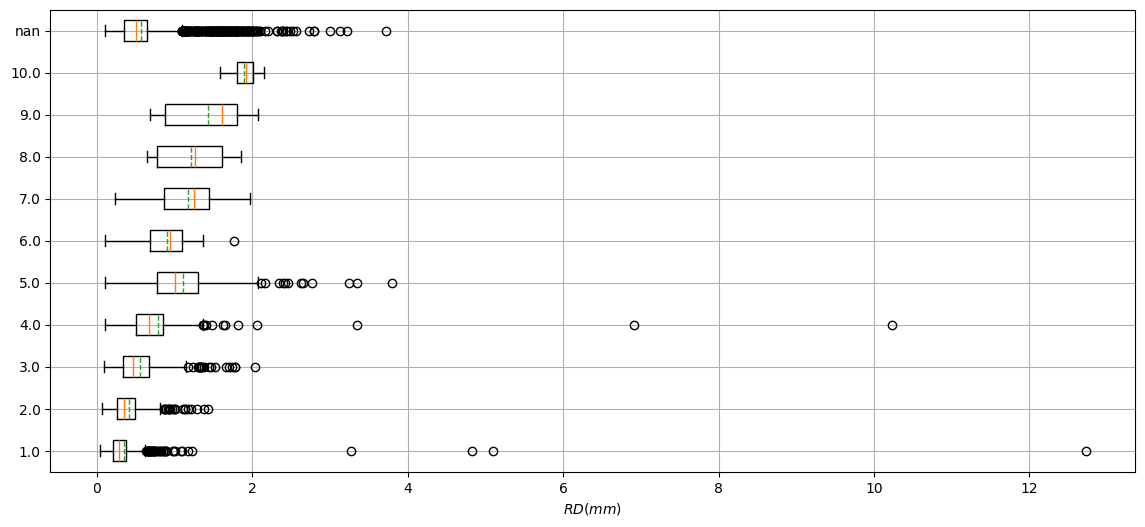

In [174]:
fig, axes = plt.subplots()
fig.set_size_inches(14, 6)
axes.boxplot([gp.F00679 for (_, gp) in collab_norord.groupby("F00056", dropna=False)], orientation="horizontal", tick_labels=[_ for (_, gp) in collab_norord.groupby("F00056", dropna=False)], showmeans=True,
            meanline=True)
axes.grid()
axes.set_xlabel(r"$RD(mm)$")
plt.show()

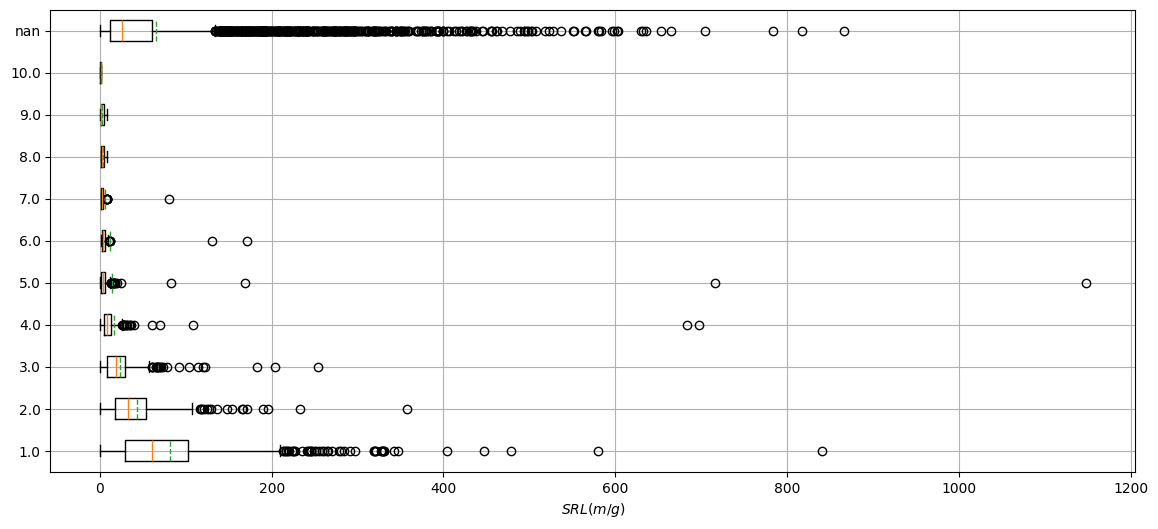

In [175]:
fig, axes = plt.subplots()
fig.set_size_inches(14, 6)
axes.boxplot([gp.F00727 for (_, gp) in collab_norord.groupby("F00056", dropna=False)], orientation="horizontal", tick_labels=[_ for (_, gp) in collab_norord.groupby("F00056", dropna=False)], showmeans=True,
            meanline=True)
axes.grid()
axes.set_xlabel(r"$SRL(m/g)$")
plt.show()

In [176]:
# DON'T THINK THIS IS A GOOD IDEA LOL
collab_norord.F00056.value_counts(dropna=False)

F00056
NaN     3207
1.0      742
3.0      340
2.0      336
4.0      244
5.0      224
6.0       41
7.0       29
8.0       14
9.0        8
10.0       4
Name: count, dtype: int64

In [21]:
collab_norord.binominal.unique().size

np.int64(1024)

In [22]:
# feels like the most sensible thing to do is to only use the root order missing data for species that do not have records with root order information
# that way, we can minimize the clean records getting skewed by not-so-clean records

collab_norord_rord_available_species = collab_norord.dropna(subset="F00056").binominal.unique() # could be any order NOT JUST THE FINE ROOT ORDERS i.e. (1, 3)
collab_norord_rord_available_species.size

np.int64(396)

In [23]:
collab_norord_rord_unavailable_species = np.setdiff1d(collab_norord.binominal.unique(), collab_norord_rord_available_species)
collab_norord_rord_unavailable_species.size # that's a LOT!!!

628

In [180]:
collab_norord_rord_available_species_1st = collab_norord.query(r"F00056==1").binominal.unique() # these are species that have first order trait info
collab_norord_rord_available_species_1st.size

np.int64(395)

In [20]:
# species that only have non-first-order root info
np.setdiff1d(collab_norord_rord_available_species, collab_norord_rord_available_species_1st) # ONLY ONE SPECIES?????

NameError: name 'collab_norord_rord_available_species' is not defined

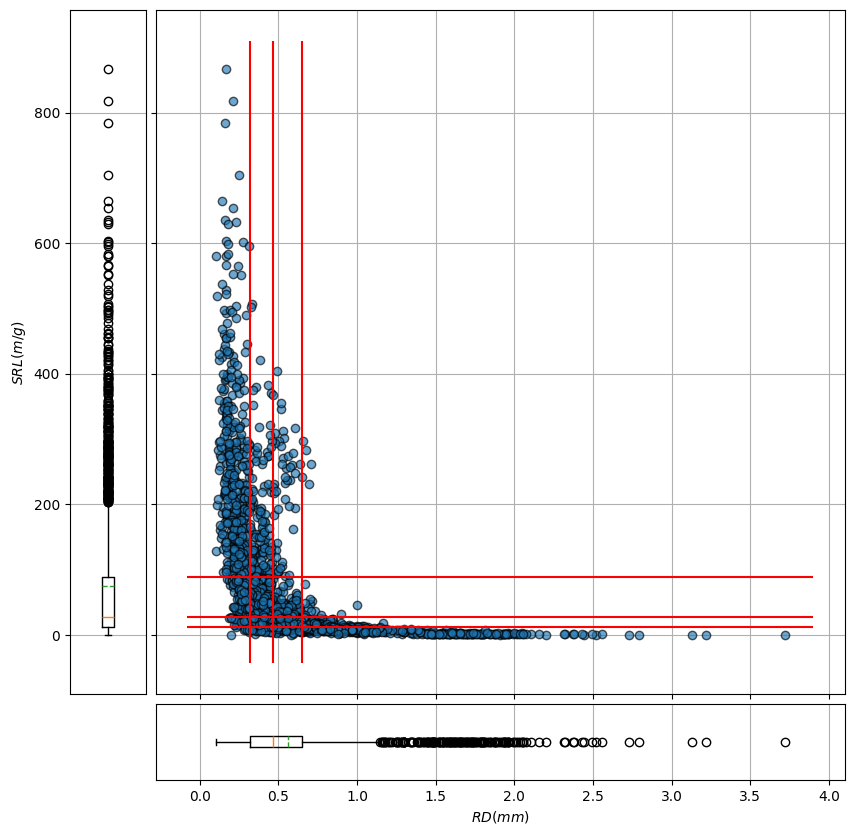

In [182]:
# species with no root order data whatsoever

rd_qntls = np.quantile(a=collab_norord.query(r"binominal.isin(@collab_norord_rord_unavailable_species)").F00679, q=(.25, .5, .75)) # RD quantiles
srl_qntls = np.quantile(a=collab_norord.query(r"binominal.isin(@collab_norord_rord_unavailable_species)").F00727, q=(.25, .5, .75)) # SRL quantiles

fig = plt.figure()
fig.set_size_inches(10, 10)
gspec = fig.add_gridspec(nrows=2, ncols=2, hspace=0.025, wspace=0.025, width_ratios=(0.1, 0.9), height_ratios=(0.9, 0.1))


axes_b = fig.add_subplot(gspec[1, 1])
axes_b.boxplot(collab_norord.query(r"binominal.isin(@collab_norord_rord_unavailable_species)").F00679, showmeans=True, meanline=True, tick_labels=None, orientation="horizontal")
axes_b.set_xlabel(r"$RD(mm)$")
axes_b.grid()
axes_b.set_yticks([])

axes_l = fig.add_subplot(gspec[0, 0])
axes_l.boxplot(collab_norord.query(r"binominal.isin(@collab_norord_rord_unavailable_species)").F00727, showmeans=True, meanline=True, tick_labels=None)
axes_l.set_ylabel(r"$SRL(m/g)$")
axes_l.grid()
axes_l.set_xticks([])

axes = fig.add_subplot(gspec[0, 1], sharex=axes_b, sharey=axes_l)
axes.scatter(x=collab_norord.query(r"binominal.isin(@collab_norord_rord_unavailable_species)").F00679, y=collab_norord.query(r"binominal.isin(@collab_norord_rord_unavailable_species)").F00727, edgecolor="black", alpha=0.65)
axes.grid()
axes.hlines(y=srl_qntls, xmin=axes.get_xlim()[0], xmax=axes.get_xlim()[1], colors="red")
axes.vlines(x=rd_qntls, ymin=axes.get_ylim()[0], ymax=axes.get_ylim()[1], colors="red")
# axes.set_xticklabels([]) # removes all the shared tick labels
# [xt.set_visible(False) for xt in axes.xaxis.get_major_ticks()] # removes the shared grid
plt.setp(axes.get_xticklabels(), visible=False)
plt.setp(axes.get_yticklabels(), visible=False)
axes.set_axisbelow(True)

plt.show()

In [183]:
# records with RD <= 1.00 mm and root order == 1
collab_norord_rdlteq1_rord1 = collab_norord.query(r"(F00679<=1.00) and (F00056==1)").groupby("binominal", as_index=False).agg({"F00679": "mean", "F00727": "mean", "F00004": "unique"})
collab_norord_rdlteq1_rord1

,binominal,F00679,F00727,F00004
0,Abelia biflora,0.529200,30.947057,"[Wang R, Wang Q, Zhao N, Xu Z, Zhu X, Jiao C, ..."
1,Abies fargesii,0.274904,30.655175,"[Pu X, Yin C, Xioa Q, Qiao M, Liu Q. 2016. Fin..."
2,Abies nephrolepis,0.415233,27.045857,"[Wang R, Wang Q, Zhao N, Xu Z, Zhu X, Jiao C, ..."
3,Acacia auriculiformis,0.334800,77.290000,"[Kong D, Ma C, Zhang Q, Li L, Chen X, Zeng H, ..."
4,Acacia crassicarpa,0.225930,108.280000,"[Kong D, Ma C, Zhang Q, Li L, Chen X, Zeng H, ..."
...,...,...,...,...
388,Veratrum nigrum,0.339600,126.313533,"[Wang R, Wang Q, Zhao N, Xu Z, Zhu X, Jiao C, ..."
389,Veronica spuria,0.186700,226.915833,"[Wang R, Wang Q, Zhao N, Xu Z, Zhu X, Jiao C, ..."
390,Vitis amurensis,0.275050,104.011337,"[Wang R, Wang Q, Zhao N, Xu Z, Zhu X, Jiao C, ..."
391,Vitis vinifera,0.146489,0.049300,"[Lavely EL, Chen W, Peterson KA, Klodd AE, Vol..."


In [184]:
#---------------------------------------------------------------------------------------------------------
# we ignore the records with only root orders other than 1 as that group consists only of 1 species
#---------------------------------------------------------------------------------------------------------

In [185]:
collab_norord.head()

,binominal,F01286,F01287,F01289,F01290,F00056,F00004,F00679,F00727
0,Acer saccharum,Acer,saccharum,Sapindaceae,Sapindales,1.0,"Pregitzer KS, Kubiske ME, Yu CK, Hendrick RL. ...",3.27,0.3
1,Acer saccharum,Acer,saccharum,Sapindaceae,Sapindales,2.0,"Pregitzer KS, Kubiske ME, Yu CK, Hendrick RL. ...",0.45,11.5
2,Acer saccharum,Acer,saccharum,Sapindaceae,Sapindales,3.0,"Pregitzer KS, Kubiske ME, Yu CK, Hendrick RL. ...",0.24,39.5
3,Acer saccharum,Acer,saccharum,Sapindaceae,Sapindales,4.0,"Pregitzer KS, Kubiske ME, Yu CK, Hendrick RL. ...",0.22,70.5
4,Acer saccharum,Acer,saccharum,Sapindaceae,Sapindales,5.0,"Pregitzer KS, Kubiske ME, Yu CK, Hendrick RL. ...",0.21,83.1


In [186]:
# records with RD <= 1.00 mm and root order unavailable
collab_norord_rdlteq1_rordnan = collab_norord.query(r"F00679<=1.00 and binominal.isin(@collab_norord_rord_unavailable_species)").groupby("binominal", as_index=False).agg({"F00679": "mean", "F00727": "mean", "F00004": "unique"})
collab_norord_rdlteq1_rordnan

,binominal,F00679,F00727,F00004
0,Abies alba,0.553000,32.026667,"[Withington JM, Reich PB, Oleksyn J, Eissensta..."
1,Acer campestre,0.421000,30.970000,"[Liese R, Alings K, Meier IC. 2017. Root branc..."
2,Achillea millefolium,0.222837,346.981438,"[Craine JM, Froehle J, Tilman DG, Wedin DA, Ch..."
3,Adinandra millettii,0.450000,218.000000,"[Fu X, Wang J, Wang H, Dai X, Yang F, Zhao M. ..."
4,Afrocarpus falcatus,0.760000,11.560000,"[Assefa D, Godbold DL, Belay B, Abiya A, Rewal..."
...,...,...,...,...
607,Weinmannia racemosa,0.378571,54.950961,"[Kramer-Walter KR, Bellingham PJ, Millar TR, S..."
608,Weinmannia silvicola,0.383120,44.072685,"[Kramer-Walter KR, Bellingham PJ, Millar TR, S..."
609,Withania frutescens,0.391800,5.831897,"[de la Riva, Navarro-Fernandez, Perez-Ramos, V..."
610,Xanthophyllum tenue,0.435750,25.229250,"[Ushio M, Fujiki Y, Hidaka A, Kitayama K. 2015..."


In [187]:
pd.concat([collab_norord_rdlteq1_rord1, collab_norord_rdlteq1_rordnan])

,binominal,F00679,F00727,F00004
0,Abelia biflora,0.529200,30.947057,"[Wang R, Wang Q, Zhao N, Xu Z, Zhu X, Jiao C, ..."
1,Abies fargesii,0.274904,30.655175,"[Pu X, Yin C, Xioa Q, Qiao M, Liu Q. 2016. Fin..."
2,Abies nephrolepis,0.415233,27.045857,"[Wang R, Wang Q, Zhao N, Xu Z, Zhu X, Jiao C, ..."
3,Acacia auriculiformis,0.334800,77.290000,"[Kong D, Ma C, Zhang Q, Li L, Chen X, Zeng H, ..."
4,Acacia crassicarpa,0.225930,108.280000,"[Kong D, Ma C, Zhang Q, Li L, Chen X, Zeng H, ..."
...,...,...,...,...
607,Weinmannia racemosa,0.378571,54.950961,"[Kramer-Walter KR, Bellingham PJ, Millar TR, S..."
608,Weinmannia silvicola,0.383120,44.072685,"[Kramer-Walter KR, Bellingham PJ, Millar TR, S..."
609,Withania frutescens,0.391800,5.831897,"[de la Riva, Navarro-Fernandez, Perez-Ramos, V..."
610,Xanthophyllum tenue,0.435750,25.229250,"[Ushio M, Fujiki Y, Hidaka A, Kitayama K. 2015..."


In [188]:
# -------------------------------------------------------------------------------------------------------------------------
# when traits with root order info is available for a species, records w/o order info for that species were ignored
# -------------------------------------------------------------------------------------------------------------------------

collab_1005sp = pd.merge(left=pd.concat([collab_norord_rdlteq1_rord1, collab_norord_rdlteq1_rordnan]), # subsets with RD <= 1.00 mm and order == 1 AND RD <= 1.000 but order missing
         left_on="binominal", right=collab_norord.loc[:, ["binominal"] + PLANT_TAXONOMY_ACCEPTED_COLUMNS].drop_duplicates(), right_on="binominal", how="left")
collab_1005sp

,binominal,F00679,F00727,F00004,F01286,F01287,F01289,F01290
0,Abelia biflora,0.529200,30.947057,"[Wang R, Wang Q, Zhao N, Xu Z, Zhu X, Jiao C, ...",Abelia,biflora,Caprifoliaceae,Dipsacales
1,Abies fargesii,0.274904,30.655175,"[Pu X, Yin C, Xioa Q, Qiao M, Liu Q. 2016. Fin...",Abies,fargesii,Pinaceae,Pinales
2,Abies nephrolepis,0.415233,27.045857,"[Wang R, Wang Q, Zhao N, Xu Z, Zhu X, Jiao C, ...",Abies,nephrolepis,Pinaceae,Pinales
3,Acacia auriculiformis,0.334800,77.290000,"[Kong D, Ma C, Zhang Q, Li L, Chen X, Zeng H, ...",Acacia,auriculiformis,Fabaceae,Fabales
4,Acacia crassicarpa,0.225930,108.280000,"[Kong D, Ma C, Zhang Q, Li L, Chen X, Zeng H, ...",Acacia,crassicarpa,Fabaceae,Fabales
...,...,...,...,...,...,...,...,...
1000,Weinmannia racemosa,0.378571,54.950961,"[Kramer-Walter KR, Bellingham PJ, Millar TR, S...",Weinmannia,racemosa,Cunoniaceae,Oxalidales
1001,Weinmannia silvicola,0.383120,44.072685,"[Kramer-Walter KR, Bellingham PJ, Millar TR, S...",Weinmannia,silvicola,Cunoniaceae,Oxalidales
1002,Withania frutescens,0.391800,5.831897,"[de la Riva, Navarro-Fernandez, Perez-Ramos, V...",Withania,frutescens,Solanaceae,Solanales
1003,Xanthophyllum tenue,0.435750,25.229250,"[Ushio M, Fujiki Y, Hidaka A, Kitayama K. 2015...",Xanthophyllum,tenue,Polygalaceae,Fabales


In [24]:
collab_1005sp.rename({
    "F00679": "RD",
    "F00727": "SRL",
    "F00004": "references",
    "F01286": "genus",
    "F01287": "species",
    "F01289": "family",
    "F01290": "order"
}, axis=1, inplace=True)

NameError: name 'collab_1005sp' is not defined

In [25]:
collab_1005sp.binominal.unique()

NameError: name 'collab_1005sp' is not defined

In [191]:
all(pd.concat([collab_norord_rdlteq1_rord1.binominal, collab_norord_rdlteq1_rordnan.binominal], ignore_index=True) == collab_1005sp.binominal)

True

In [192]:
collab_1005sp.insert(column="root_order", value=np.repeat(a=[1, np.nan], repeats=[collab_norord_rdlteq1_rord1.shape[0], collab_norord_rdlteq1_rordnan.shape[0]]), loc=1) # root order info

In [193]:
assert all(collab_1005sp.query("root_order==1").binominal == collab_norord_rdlteq1_rord1.binominal)
assert all(collab_1005sp.query("root_order.isna()").binominal.values == collab_norord_rdlteq1_rordnan.binominal)

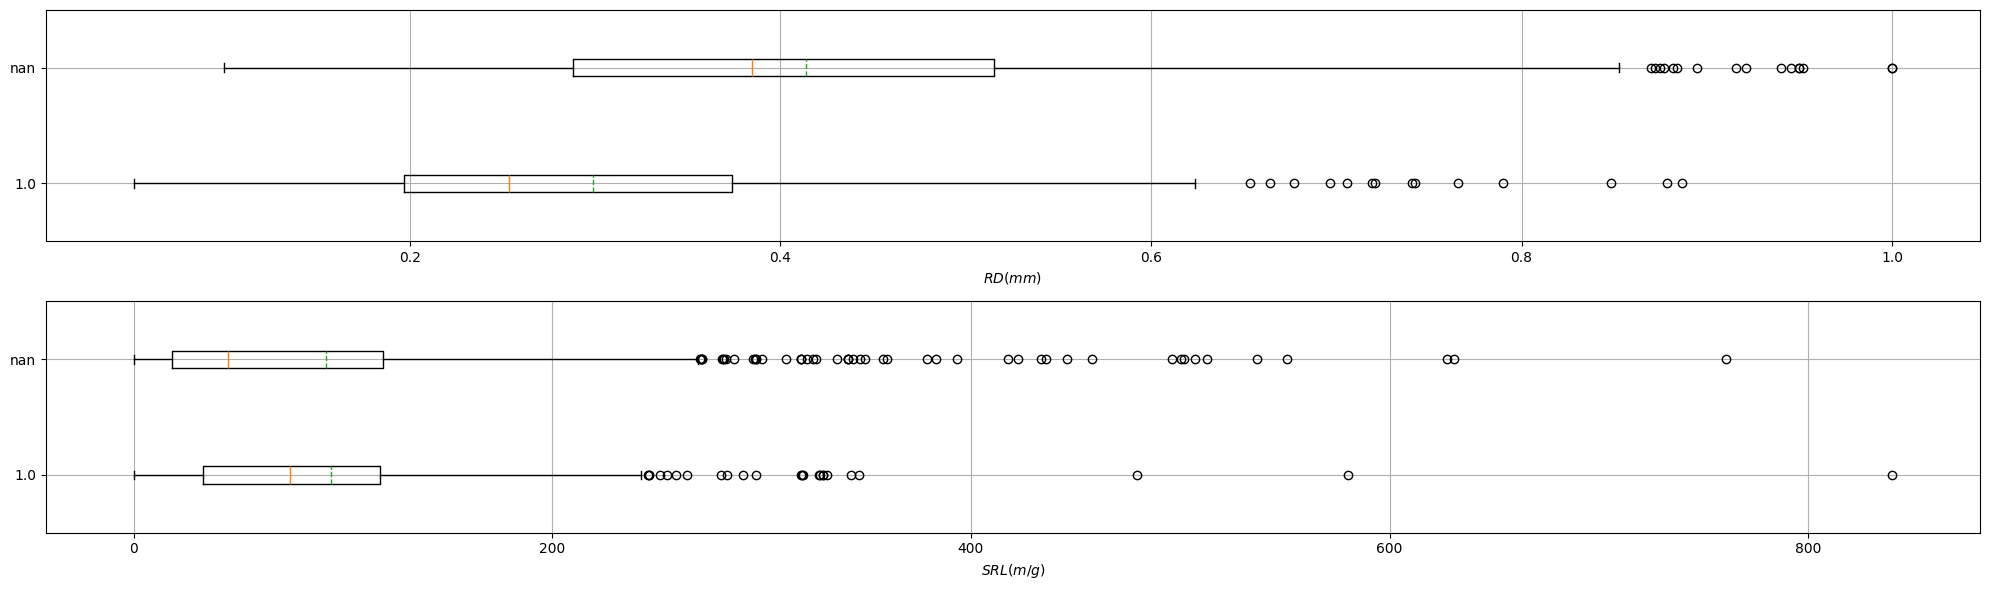

In [194]:
fig, (axes_0, axes_1) = plt.subplots(nrows=2, sharex=False, sharey=False)
fig.set_size_inches(20, 6)

axes_0.boxplot([gp.RD for (_, gp) in collab_1005sp.groupby("root_order", dropna=False)], orientation="horizontal", tick_labels=[_ for (_, gp) in collab_1005sp.groupby("root_order", dropna=False)], showmeans=True, meanline=True)
axes_0.grid()
axes_0.set_xlabel(r"$RD(mm)$")

axes_1.boxplot([gp.SRL for (_, gp) in collab_1005sp.groupby("root_order", dropna=False)], orientation="horizontal", tick_labels=[_ for (_, gp) in collab_1005sp.groupby("root_order", dropna=False)], showmeans=True, meanline=True)
axes_1.grid()
axes_1.set_xlabel(r"$SRL(m/g)$")

plt.tight_layout()
plt.show()

In [195]:
# without log transforming the continuous traits
collab_1005sp.to_csv(r"../../data/chapter2/FREDv3subset/collab_rdlteq1_rd1ornan_RD_SRL_species_avgd.csv", index=False)

In [196]:
# log transform the continuous traits
collab_1005sp.loc[:, "RD"] = np.log(collab_1005sp.RD)
collab_1005sp.loc[:, "SRL"] = np.log(collab_1005sp.SRL)
collab_1005sp.to_csv(r"../../data/chapter2/FREDv3subset/collab_rdlteq1_rd1ornan_log_RD_SRL_species_avgd.csv", index=False)